# Plan1c k40 full regularization-path analysis

This notebook visualizes LR path behavior for the completed full-range run:

- penalties: `l1`, `l2`, `elasticnet`
- alpha grid: `10^-4` to `10^5` with 20 points
- CV modes: `pooled_cv` (default) and optionally `per_patient_cv`
- all DR methods and downsampling settings discovered from disk

The downstream pooled analysis now focuses on selecting the most parsimonious non-zero sparse model, rather than allowing the path endpoint to collapse to the all-zero solution for `l1` or `elasticnet`.

Outputs are saved under the notebook output directory.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context("talk")
sns.set_style("whitegrid")

RESULT_ROOT = Path(
    "/home/minhang/mds_project/sc_classification/experiments/20260211_212806_plan0_k_sweep_60_none_hvg_c06f4886/models/classification/plan1c_supervised_latent_k40_full_all"
)

OUTPUT_DIR = Path(
    "/home/minhang/mds_project/sc_classification/scripts/comprehensive_run/notebooks/outputs/plan1c_k40_full_reg_path_analysis_20260319"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"RESULT_ROOT: {RESULT_ROOT}")
print(f"OUTPUT_DIR:   {OUTPUT_DIR}")

RESULT_ROOT: /home/minhang/mds_project/sc_classification/experiments/20260211_212806_plan0_k_sweep_60_none_hvg_c06f4886/models/classification/plan1c_supervised_latent_k40_full_all
OUTPUT_DIR:   /home/minhang/mds_project/sc_classification/scripts/comprehensive_run/notebooks/outputs/plan1c_k40_full_reg_path_analysis_20260319


In [2]:
def discover_available_runs(result_root: Path, cv_mode: str = "pooled_cv") -> pd.DataFrame:
    rows = []
    # check if we have a pooled_cv (across all patients)
    if cv_mode == "pooled_cv":
        pattern = "*/*/coefficient_path_*.csv"
        for path in sorted((result_root / cv_mode).glob(pattern)):
            method = path.parent.parent.name
            downsampling = path.parent.name
            penalty = path.stem.replace("coefficient_path_", "")
            rows.append(
                {
                    "cv_mode": cv_mode,
                    "method": method,
                    "downsampling": downsampling,
                    "penalty": penalty,
                    "patient": None,
                    "coef_path": path,
                    "metrics_path": path.with_name(path.name.replace("coefficient_path_", "grid_metrics_")),
                }
            )
    # check if we have a per_patient_cv (individual patient classification)
    elif cv_mode == "per_patient_cv":
        pattern = "*/*/*_coefficient_path_*.csv"
        for path in sorted((result_root / cv_mode).glob(pattern)):
            method = path.parent.parent.name
            downsampling = path.parent.name
            name = path.stem
            patient, suffix = name.split("_coefficient_path_", maxsplit=1)
            penalty = suffix
            rows.append(
                {
                    "cv_mode": cv_mode,
                    "method": method,
                    "downsampling": downsampling,
                    "penalty": penalty,
                    "patient": patient,
                    "coef_path": path,
                    "metrics_path": path.with_name(path.name.replace("_coefficient_path_", "_grid_metrics_")),
                }
            )
    else:
        raise ValueError("cv_mode must be 'pooled_cv' or 'per_patient_cv'")

    df = pd.DataFrame(rows)
    if df.empty:
        raise FileNotFoundError(f"No runs found under {result_root / cv_mode}")
    return df


# in this notebook, we will focus on the across-patient analysis
pooled_index = discover_available_runs(RESULT_ROOT, cv_mode="pooled_cv")
print(f"Discovered pooled runs: {len(pooled_index)}")
display(
    pooled_index[["method", "downsampling", "penalty"]]
    .drop_duplicates()
    .sort_values(["method", "downsampling", "penalty"])
    .reset_index(drop=True)
)

Discovered pooled runs: 30


,method,downsampling,penalty
0,cnmf,none,elasticnet
1,cnmf,none,l1
2,cnmf,none,l2
3,cnmf,random,elasticnet
4,cnmf,random,l1
5,cnmf,random,l2
6,fa,none,elasticnet
7,fa,none,l1
8,fa,none,l2
9,fa,random,elasticnet


In [3]:
# load a pair of coefficient and metrics
def load_pair(row: pd.Series) -> tuple[pd.DataFrame, pd.DataFrame]:
    coef_df = pd.read_csv(row["coef_path"])
    metrics_df = pd.read_csv(row["metrics_path"])

    numeric_cols = [
        "alpha",
        "coef",
        "abs_coef",
        "is_nonzero",
        "l1_ratio",
        "auc_mean",
        "auc_std",
        "ap_mean",
        "ap_std",
        "acc_mean",
        "acc_std",
        "nonzero_coef_count_full_refit",
    ]
    for col in numeric_cols:
        if col in coef_df.columns:
            coef_df[col] = pd.to_numeric(coef_df[col], errors="coerce")
        if col in metrics_df.columns:
            metrics_df[col] = pd.to_numeric(metrics_df[col], errors="coerce")

    return coef_df, metrics_df


def pretty_downsampling(value: str) -> str:
    return "no-downsampling" if str(value).lower() == "none" else str(value)


def get_class_counts_from_oof(row: pd.Series) -> dict | None:
    """Return class counts from best-OOF file if available.

    We use y=1 as malignant and y=0 as healthy/normal.
    """
    oof_path = row["metrics_path"].with_name(f"oof_predictions_best_{row['penalty']}.csv")
    if not oof_path.exists():
        return None

    oof_df = pd.read_csv(oof_path, usecols=["y"])
    vc = oof_df["y"].value_counts(dropna=False)
    return {
        "malignant": int(vc.get(1, 0)),
        "healthy": int(vc.get(0, 0)),
    }

# filter the dataframe by l1_ratio
def _filter_ratio(df: pd.DataFrame, l1_ratio: float | None) -> pd.DataFrame:
    if "l1_ratio" not in df.columns:
        return df.copy()
    if l1_ratio is None:
        return df[df["l1_ratio"].isna()]
    return df[np.isclose(df["l1_ratio"], l1_ratio, atol=1e-12)]

def _errorbar_or_line(ax, x, y, yerr, label, marker):
    if yerr is not None:
        ax.errorbar(
            x,
            y,
            yerr=yerr,
            fmt=f"{marker}-",
            markersize=5,
            capsize=4,
            capthick=1.1,
            elinewidth=1.2,
            lw=1.8,
            label=label,
        )
    else:
        ax.plot(x, y, marker=marker, markersize=5, lw=2, label=label)


# plotting the metrics
def plot_metric_panel(ax, metrics_sub: pd.DataFrame, title: str, class_counts: dict | None = None):
    m = metrics_sub.sort_values("alpha")
    x = m["alpha"].values

    auc_std = m["auc_std"] if "auc_std" in m.columns else None
    _errorbar_or_line(ax, x, m["auc_mean"], auc_std, "AUC", "o")

    if "ap_mean" in m.columns:
        ap_std = m["ap_std"] if "ap_std" in m.columns else None
        _errorbar_or_line(ax, x, m["ap_mean"], ap_std, "AP", "s")

    if "acc_mean" in m.columns:
        acc_std = m["acc_std"] if "acc_std" in m.columns else None
        _errorbar_or_line(ax, x, m["acc_mean"], acc_std, "Accuracy", "^")

    ax.set_xscale("log")
    ax.set_xlabel("alpha (log scale)")
    ax.set_ylabel("metric")
    ax.set_title(title)

    handles, labels = ax.get_legend_handles_labels()

    if "nonzero_coef_count_full_refit" in m.columns:
        ax2 = ax.twinx()
        ax2.plot(
            x,
            m["nonzero_coef_count_full_refit"],
            color="black",
            linestyle="--",
            marker=".",
            label="nonzero coefs",
        )
        ax2.set_ylabel("nonzero coefficients")
        h2, l2 = ax2.get_legend_handles_labels()
        handles.extend(h2)
        labels.extend(l2)

    if class_counts is not None:
        handles.extend(
            [
                plt.Line2D([], [], linestyle="none", marker="", label=f"Malignant cells: {class_counts['malignant']}"),
                plt.Line2D([], [], linestyle="none", marker="", label=f"Healthy cells: {class_counts['healthy']}"),
            ]
        )
        labels.extend(
            [
                f"Malignant cells: {class_counts['malignant']}",
                f"Healthy cells: {class_counts['healthy']}",
            ]
        )

    ax.legend(
        handles,
        labels,
        loc="upper left",
        bbox_to_anchor=(1.14, 1.0),
        borderaxespad=0,
        fontsize=9,
        frameon=True,
    )

# plotting the coefficient paths
def plot_coefficient_paths_panel(ax, coef_sub: pd.DataFrame, top_k: int = 12):
    coef_sub = coef_sub.copy()
    ranked = (
        coef_sub.groupby("feature")["abs_coef"]
        .max()
        .sort_values(ascending=False)
        .head(top_k)
        .index
    )
    c = coef_sub[coef_sub["feature"].isin(ranked)].sort_values(["feature", "alpha"])

    for feat, g in c.groupby("feature"):
        feat_label = str(feat)
        if isinstance(feat, (int, float, np.integer, np.floating)):
            feat_label = f"f{int(feat)}"
        ax.plot(g["alpha"], g["coef"], lw=1.6, alpha=0.9, label=feat_label)

    ax.axhline(0.0, color="black", lw=1)
    ax.set_xscale("log")
    ax.set_xlabel("alpha (log scale)")
    ax.set_ylabel("coefficient")
    ax.set_title(f"Top-{top_k} coefficient paths")
    ax.legend(
        loc="upper left",
        bbox_to_anchor=(1.06, 1.0),
        borderaxespad=0,
        fontsize=8,
        title="Factor",
        frameon=True,
    )

# plotting the standard report, which is a combination of metrics and coefficient paths
def plot_standard_report(
    coef_df: pd.DataFrame,
    metrics_df: pd.DataFrame,
    title: str,
    l1_ratio: float | None = None,
    top_k: int = 12,
    class_counts: dict | None = None,
):
    coef_sub = _filter_ratio(coef_df, l1_ratio)
    metrics_sub = _filter_ratio(metrics_df, l1_ratio)

    if coef_sub.empty or metrics_sub.empty:
        raise ValueError("No rows left after l1_ratio filtering.")

    fig, axes = plt.subplots(2, 1, figsize=(18, 10), constrained_layout=True)

    ratio_suffix = ""
    if l1_ratio is not None:
        ratio_suffix = f" | l1_ratio={l1_ratio:g}"

    plot_metric_panel(axes[0], metrics_sub, title + ratio_suffix, class_counts=class_counts)
    plot_coefficient_paths_panel(axes[1], coef_sub, top_k=top_k)

    return fig

# plotting the elastic-net heatmaps
def plot_elasticnet_heatmaps(metrics_df: pd.DataFrame, title: str):
    m = metrics_df.dropna(subset=["l1_ratio"]).copy()
    if m.empty:
        raise ValueError("No elastic-net rows with l1_ratio found.")

    auc_pivot = m.pivot_table(index="l1_ratio", columns="alpha", values="auc_mean", aggfunc="mean")
    nz_pivot = m.pivot_table(index="l1_ratio", columns="alpha", values="nonzero_coef_count_full_refit", aggfunc="mean")

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)
    sns.heatmap(auc_pivot, cmap="viridis", ax=axes[0])
    axes[0].set_title(f"{title} | AUC heatmap")
    axes[0].set_xlabel("alpha")
    axes[0].set_ylabel("l1_ratio")

    sns.heatmap(nz_pivot, cmap="magma", ax=axes[1])
    axes[1].set_title(f"{title} | nonzero coef count")
    axes[1].set_xlabel("alpha")
    axes[1].set_ylabel("l1_ratio")

    return fig

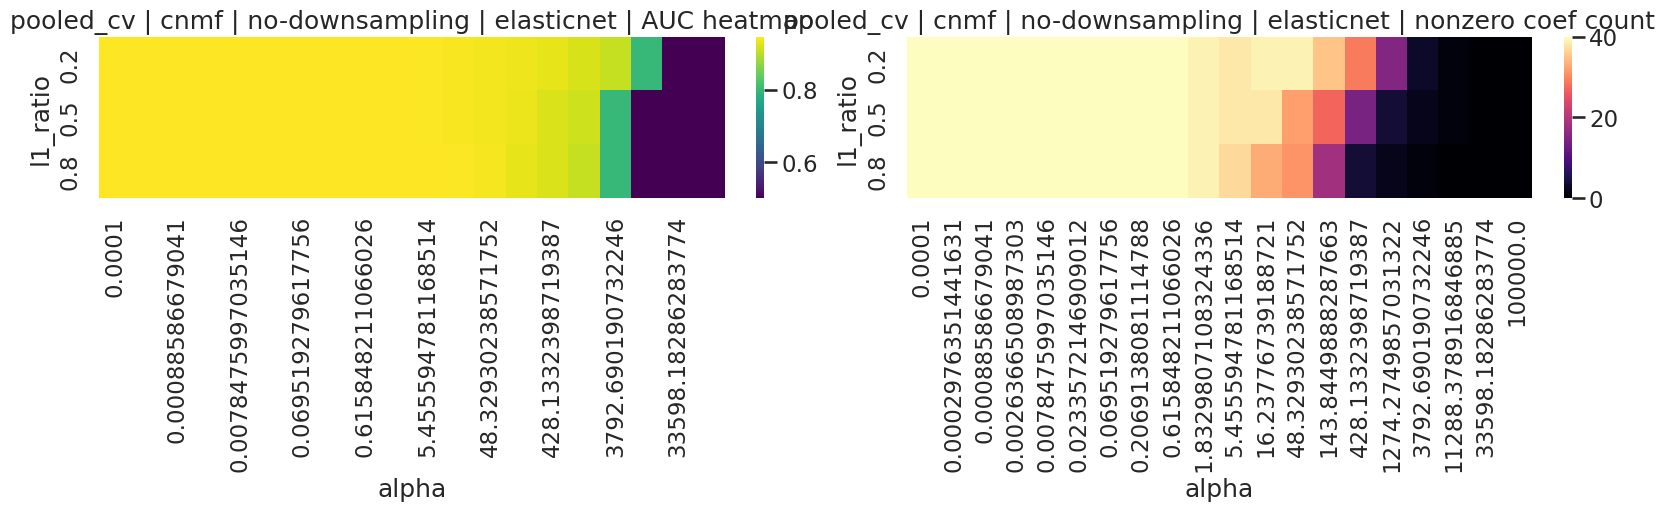

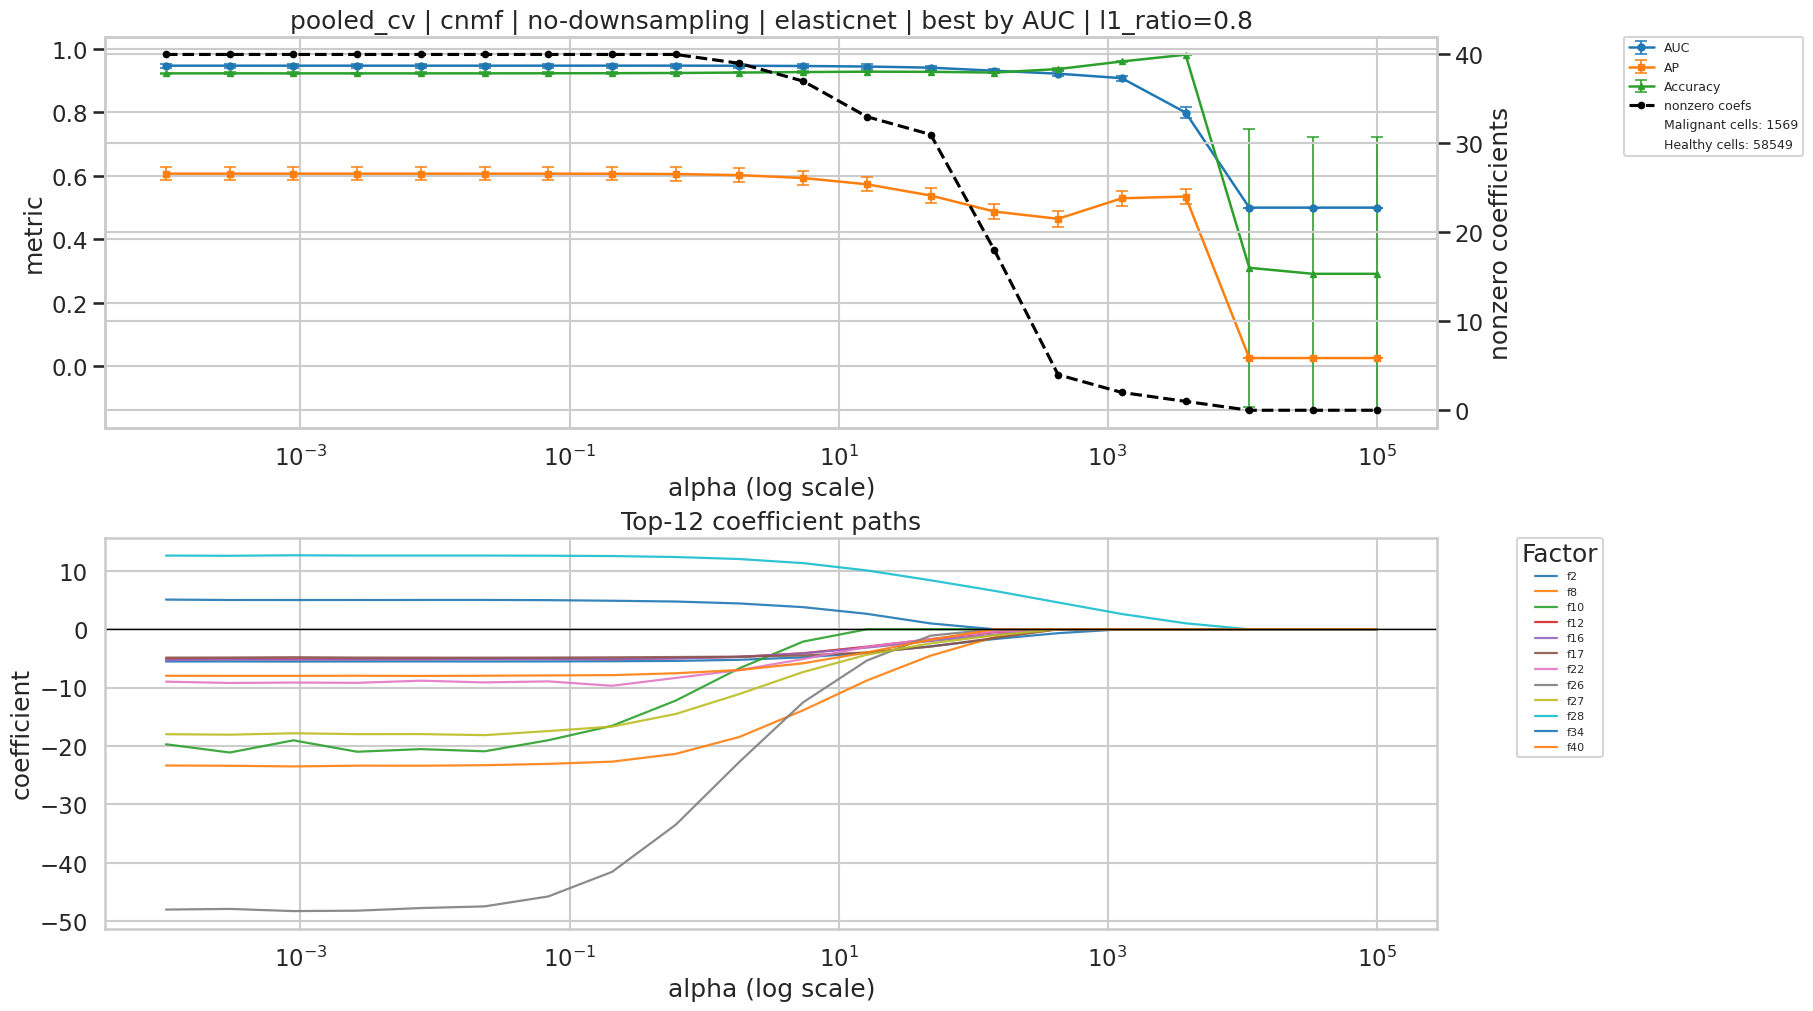

Best elastic-net config by AUC: alpha=0.2069, l1_ratio=0.8, AUC=0.9473


In [4]:
# Elastic-net example: heatmaps + best-l1_ratio path plot
example_en = pooled_index.query("method == 'cnmf' and downsampling == 'none' and penalty == 'elasticnet'").iloc[0]
coef_en, metrics_en = load_pair(example_en)
class_counts_en = get_class_counts_from_oof(example_en)

en_title = f"pooled_cv | {example_en.method} | {pretty_downsampling(example_en.downsampling)} | elasticnet"

fig_hm = plot_elasticnet_heatmaps(metrics_en, en_title)
plt.show()
plt.close(fig_hm)

best_row = metrics_en.loc[metrics_en["auc_mean"].idxmax()]
best_ratio = float(best_row["l1_ratio"])

fig_best = plot_standard_report(
    coef_en,
    metrics_en,
    title=en_title + " | best by AUC",
    l1_ratio=best_ratio,
    top_k=12,
    class_counts=class_counts_en,
)
plt.show()
plt.close(fig_best)

print(f"Best elastic-net config by AUC: alpha={best_row['alpha']:.4g}, l1_ratio={best_ratio:.3g}, AUC={best_row['auc_mean']:.4f}")

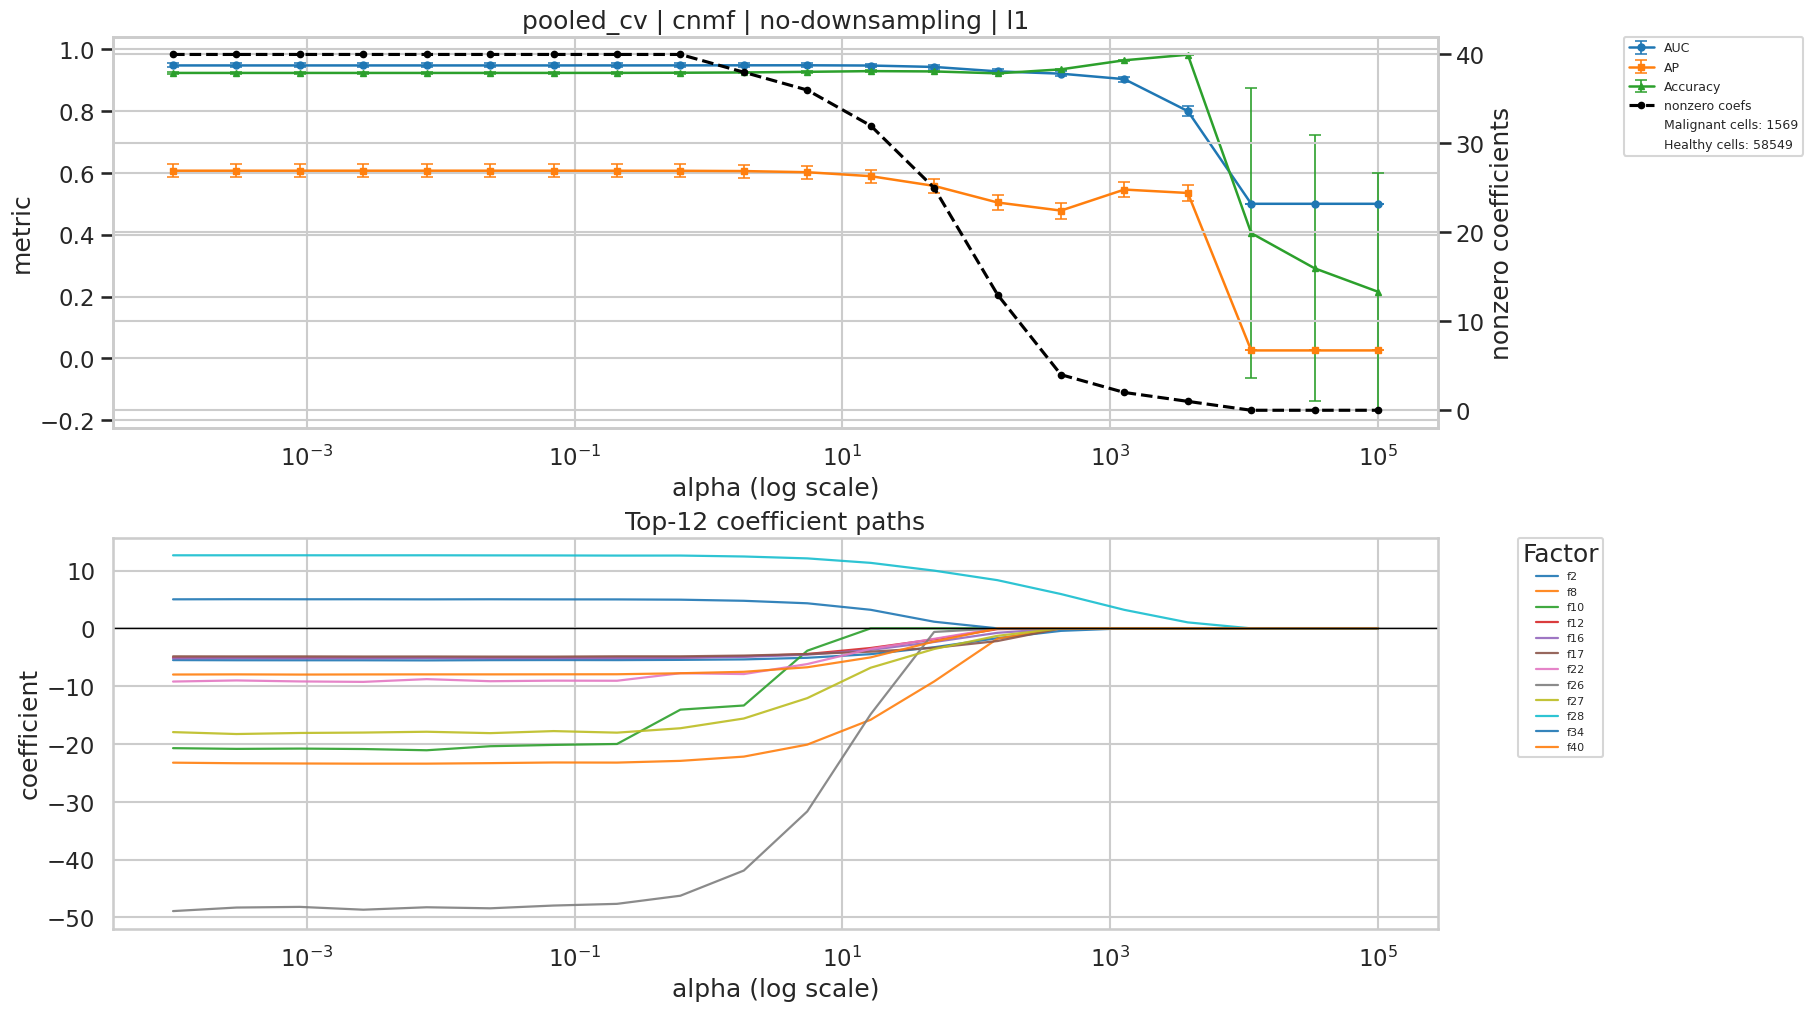

In [5]:
# L1 example: heatmaps + best-alpha path plot
example_L1 = pooled_index.query("method == 'cnmf' and downsampling == 'none' and penalty == 'l1'").iloc[0]
coef_L1, metrics_L1 = load_pair(example_L1)
class_counts_L1 = get_class_counts_from_oof(example_L1)

L1_title = f"pooled_cv | {example_L1.method} | {pretty_downsampling(example_L1.downsampling)} | l1"

fig_L1 = plot_standard_report(
    coef_L1,
    metrics_L1,
    title=L1_title,
    l1_ratio=None,
    top_k=12,
    class_counts=class_counts_L1,
)
plt.show()
plt.close(fig_L1)



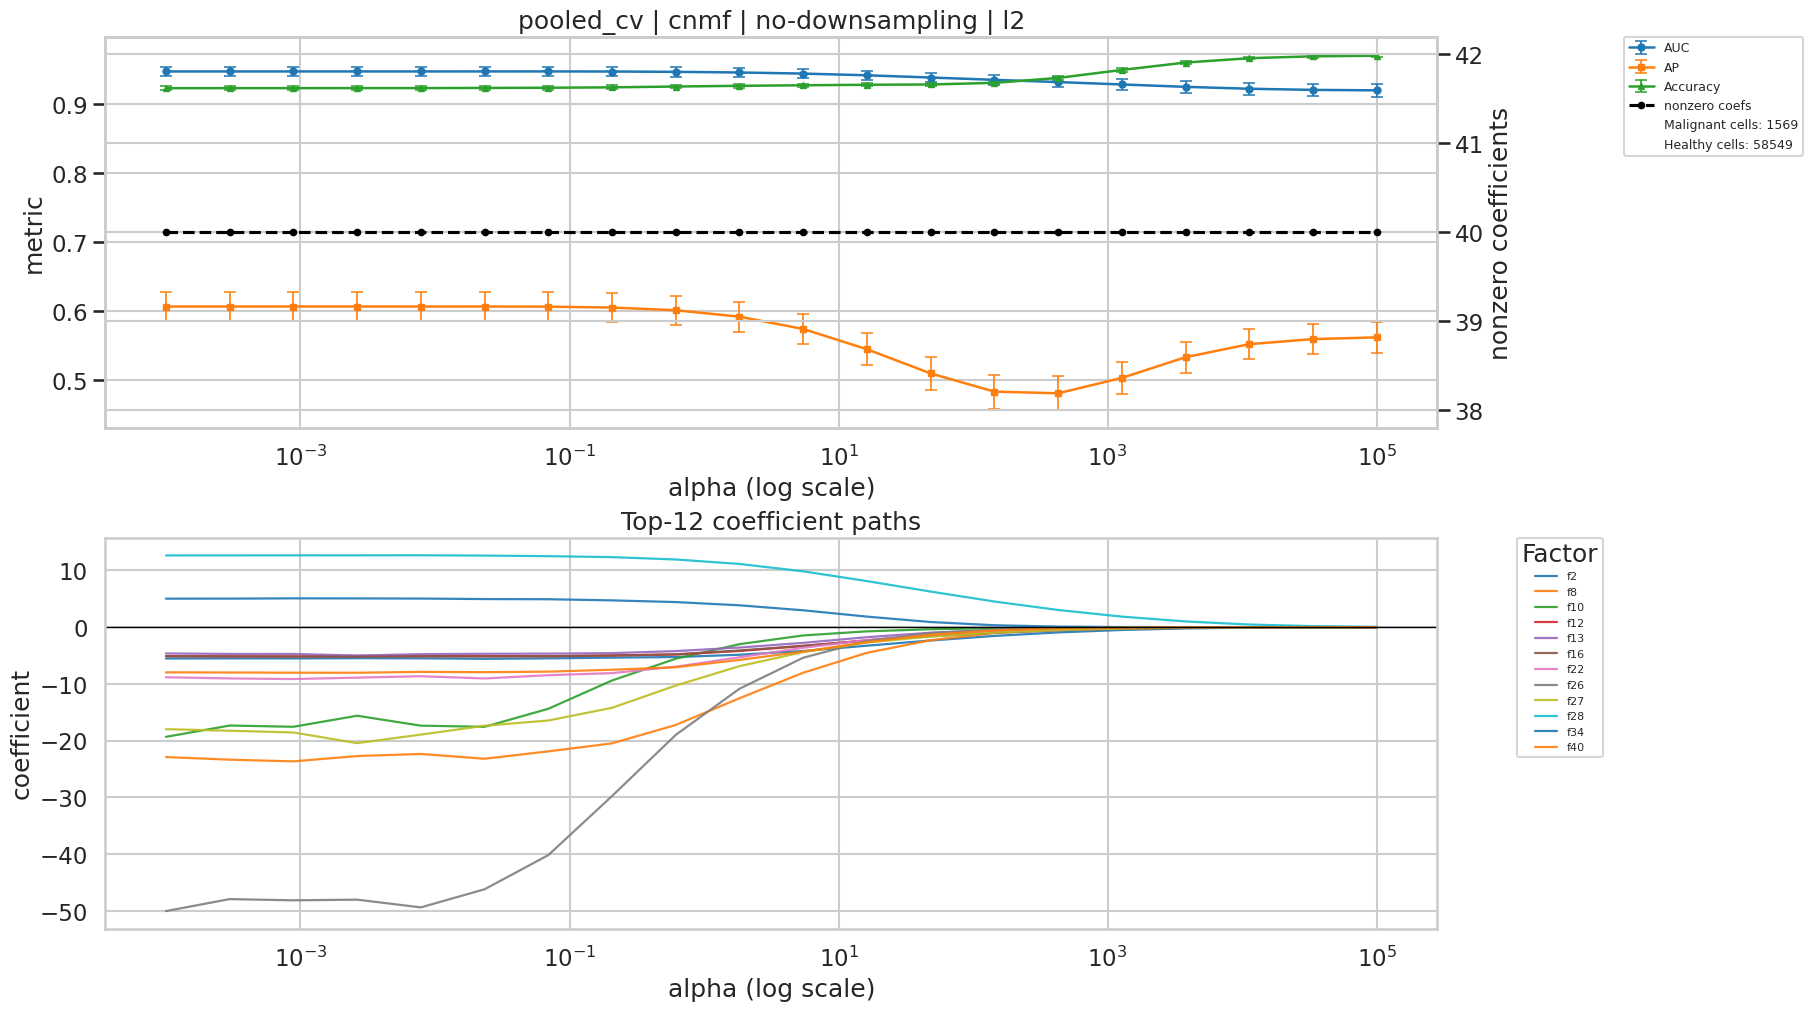

In [6]:
# L2 example: heatmaps + best-alpha path plot
example_L2 = pooled_index.query("method == 'cnmf' and downsampling == 'none' and penalty == 'l2'").iloc[0]
coef_L2, metrics_L2 = load_pair(example_L2)
class_counts_L2 = get_class_counts_from_oof(example_L2)

L2_title = f"pooled_cv | {example_L2.method} | {pretty_downsampling(example_L2.downsampling)} | l2"

fig_L2 = plot_standard_report(
    coef_L2,
    metrics_L2,
    title=L2_title,
    l1_ratio=None,
    top_k=12,
    class_counts=class_counts_L2,
)
plt.show()
plt.close(fig_L2)

In [7]:
# Batch export for ALL pooled CV runs
saved = []

for _, row in pooled_index.sort_values(["method", "downsampling", "penalty"]).iterrows():
    coef_df, metrics_df = load_pair(row)
    class_counts = get_class_counts_from_oof(row)
    base_name = f"pooled__{row.method}__{row.downsampling}__{row.penalty}"
    downsampling_display = pretty_downsampling(row.downsampling)
    title = f"pooled_cv | {row.method} | {downsampling_display} | {row.penalty}"

    if row.penalty in {"l1", "l2"}:
        fig = plot_standard_report(
            coef_df,
            metrics_df,
            title=title,
            l1_ratio=None,
            top_k=12,
            class_counts=class_counts,
        )
        out = OUTPUT_DIR / f"{base_name}.png"
        fig.savefig(out, dpi=200, bbox_inches="tight")
        plt.close(fig)
        saved.append(out)

    elif row.penalty == "elasticnet":
        # 1) global elastic-net overview across (alpha, l1_ratio)
        fig_hm = plot_elasticnet_heatmaps(metrics_df, title)
        out_hm = OUTPUT_DIR / f"{base_name}__heatmaps.png"
        fig_hm.savefig(out_hm, dpi=200, bbox_inches="tight")
        plt.close(fig_hm)
        saved.append(out_hm)

        # 2) path report at best (alpha, l1_ratio) by AUC
        best_row = metrics_df.loc[metrics_df["auc_mean"].idxmax()]
        best_ratio = float(best_row["l1_ratio"])
        fig_best = plot_standard_report(
            coef_df,
            metrics_df,
            title=title + " | best by AUC",
            l1_ratio=best_ratio,
            top_k=12,
            class_counts=class_counts,
        )
        out_best = OUTPUT_DIR / f"{base_name}__best_ratio_{best_ratio:g}.png"
        fig_best.savefig(out_best, dpi=200, bbox_inches="tight")
        plt.close(fig_best)
        saved.append(out_best)

print(f"Saved {len(saved)} figures to {OUTPUT_DIR}")
display(pd.DataFrame({"file": [str(p) for p in saved]}).head(20))

Saved 40 figures to /home/minhang/mds_project/sc_classification/scripts/comprehensive_run/notebooks/outputs/plan1c_k40_full_reg_path_analysis_20260319


,file
0,/home/minhang/mds_project/sc_classification/sc...
1,/home/minhang/mds_project/sc_classification/sc...
2,/home/minhang/mds_project/sc_classification/sc...
3,/home/minhang/mds_project/sc_classification/sc...
4,/home/minhang/mds_project/sc_classification/sc...
5,/home/minhang/mds_project/sc_classification/sc...
6,/home/minhang/mds_project/sc_classification/sc...
7,/home/minhang/mds_project/sc_classification/sc...
8,/home/minhang/mds_project/sc_classification/sc...
9,/home/minhang/mds_project/sc_classification/sc...


## Pooled model-selection and cross-DR signature analysis

This section mirrors the downstream pooled analyses from the earlier notebook, but updates the model-selection rule for the expanded alpha grid.

Current focus:

1. Use a unified selector with a `selection_mode` argument.
2. For `most_parsimonious_nonzero`, treat `l1` and `elasticnet` as sparse penalties and exclude all-zero solutions before choosing the strongest regularization.
3. Keep `l2` unchanged, since it stays dense across the path.
4. Preserve the downstream pooled analyses: downsampling report, predictive gene signatures, cross-model similarity, top-200 gene overlap, and Hallmark GSEA NES heatmap.

Important interpretation note:

- The performance metrics in `grid_metrics_*.csv` are CV metrics computed on held-out validation folds and then summarized across repeated CV.
- The coefficient vectors and `nonzero_coef_count_full_refit` come from full-data refits at each alpha and are used for sparsity/path interpretation.

So the selected point combines held-out CV performance estimates with the full-data coefficient path at the same hyperparameter setting.

EXP_DIR: /home/minhang/mds_project/sc_classification/experiments/20260211_212806_plan0_k_sweep_60_none_hvg_c06f4886
SELECTION_MODE: most_parsimonious_nonzero


,method,downsampling_display,penalty,selected_alpha,selected_l1_ratio,mal_recall_mean,auc_mean,ap_mean,nonzero_coef_count_full_refit,strongest_alpha_has_any_nonzero
0,cnmf,no-downsampling,elasticnet,11288.378917,0.5,0.680000,0.500000,0.026099,1.0,False
1,cnmf,no-downsampling,l1,3792.690191,NaN,0.481255,0.799600,0.534976,1.0,False
2,cnmf,no-downsampling,l2,100000.000000,NaN,0.527911,0.919806,0.562224,40.0,True
3,cnmf,random,elasticnet,3792.690191,0.5,1.000000,0.500000,0.088121,1.0,False
4,cnmf,random,l1,1274.274986,NaN,0.479094,0.799773,0.620093,1.0,False
5,cnmf,random,l2,100000.000000,NaN,0.524345,0.918630,0.706839,40.0,True
6,fa,no-downsampling,elasticnet,100000.000000,0.2,0.481319,0.774145,0.473813,1.0,True
7,fa,no-downsampling,l1,33598.182863,NaN,0.479662,0.774145,0.473813,1.0,False
8,fa,no-downsampling,l2,100000.000000,NaN,0.560092,0.950809,0.642489,40.0,True
9,fa,random,elasticnet,33598.182863,0.2,0.480434,0.773694,0.571784,1.0,False


Selected nonzero-factor counts:


nonzero_coef_count_full_refit
1.0     12
2.0      2
3.0      1
7.0      1
11.0     1
15.0     1
18.0     1
22.0     1
40.0    10
Name: count, dtype: int64

Sparse-penalty diagnostic summary:


,method,downsampling_display,penalty,selected_alpha,selected_l1_ratio,nonzero_coef_count_full_refit,strongest_alpha,strongest_alpha_has_any_nonzero
0,cnmf,no-downsampling,elasticnet,11288.378917,0.5,1.0,100000.0,False
1,cnmf,random,elasticnet,3792.690191,0.5,1.0,100000.0,False
2,fa,no-downsampling,elasticnet,100000.000000,0.2,1.0,100000.0,True
3,fa,random,elasticnet,33598.182863,0.2,1.0,100000.0,False
4,factosig,no-downsampling,elasticnet,100000.000000,0.5,1.0,100000.0,True
5,factosig,random,elasticnet,33598.182863,0.2,1.0,100000.0,False
6,factosig_promax,no-downsampling,elasticnet,100000.000000,0.2,22.0,100000.0,True
7,factosig_promax,random,elasticnet,100000.000000,0.2,18.0,100000.0,True
8,pca,no-downsampling,elasticnet,100000.000000,0.2,7.0,100000.0,True
9,pca,random,elasticnet,100000.000000,0.2,3.0,100000.0,True


Saved selection table to: /home/minhang/mds_project/sc_classification/scripts/comprehensive_run/notebooks/outputs/plan1c_k40_full_reg_path_analysis_20260319/pooled_selected_models__most_parsimonious_nonzero.csv


,method,penalty,selected_alpha_none,selected_alpha_random,selected_l1_ratio_none,selected_l1_ratio_random,delta_mal_recall_mean,delta_auc_mean,delta_ap_mean,delta_acc_mean,delta_nonzero_coef_count_full_refit
0,cnmf,elasticnet,11288.378917,3792.690191,0.5,0.5,0.320000,0.000000,0.062023,-0.241264,0.0
1,cnmf,l1,3792.690191,1274.274986,NaN,NaN,-0.002162,0.000173,0.085116,-0.031944,0.0
2,cnmf,l2,100000.000000,100000.000000,NaN,NaN,-0.003566,-0.001176,0.144615,-0.028225,0.0
3,fa,elasticnet,100000.000000,33598.182863,0.2,0.2,-0.000885,-0.000450,0.097971,-0.031400,0.0
4,fa,l1,33598.182863,11288.378917,NaN,NaN,0.520338,-0.274145,-0.385691,-0.887252,0.0
5,fa,l2,100000.000000,100000.000000,NaN,NaN,-0.042885,-0.002219,0.145054,-0.023696,0.0
6,factosig,elasticnet,100000.000000,33598.182863,0.5,0.2,-0.302308,0.316383,0.626261,0.719028,0.0
7,factosig,l1,33598.182863,11288.378917,NaN,NaN,-0.000886,0.000633,0.077352,-0.032754,0.0
8,factosig,l2,100000.000000,100000.000000,NaN,NaN,-0.048559,-0.002204,0.144904,-0.023405,0.0
9,factosig_promax,elasticnet,100000.000000,100000.000000,0.2,0.2,-0.061569,-0.021293,0.099136,-0.020586,-4.0


/tmp/ipykernel_1397821/1025269921.py:207: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot = p.applymap(_format_annotation)
/tmp/ipykernel_1397821/1025269921.py:207: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot = p.applymap(_format_annotation)
/tmp/ipykernel_1397821/1025269921.py:207: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot = p.applymap(_format_annotation)


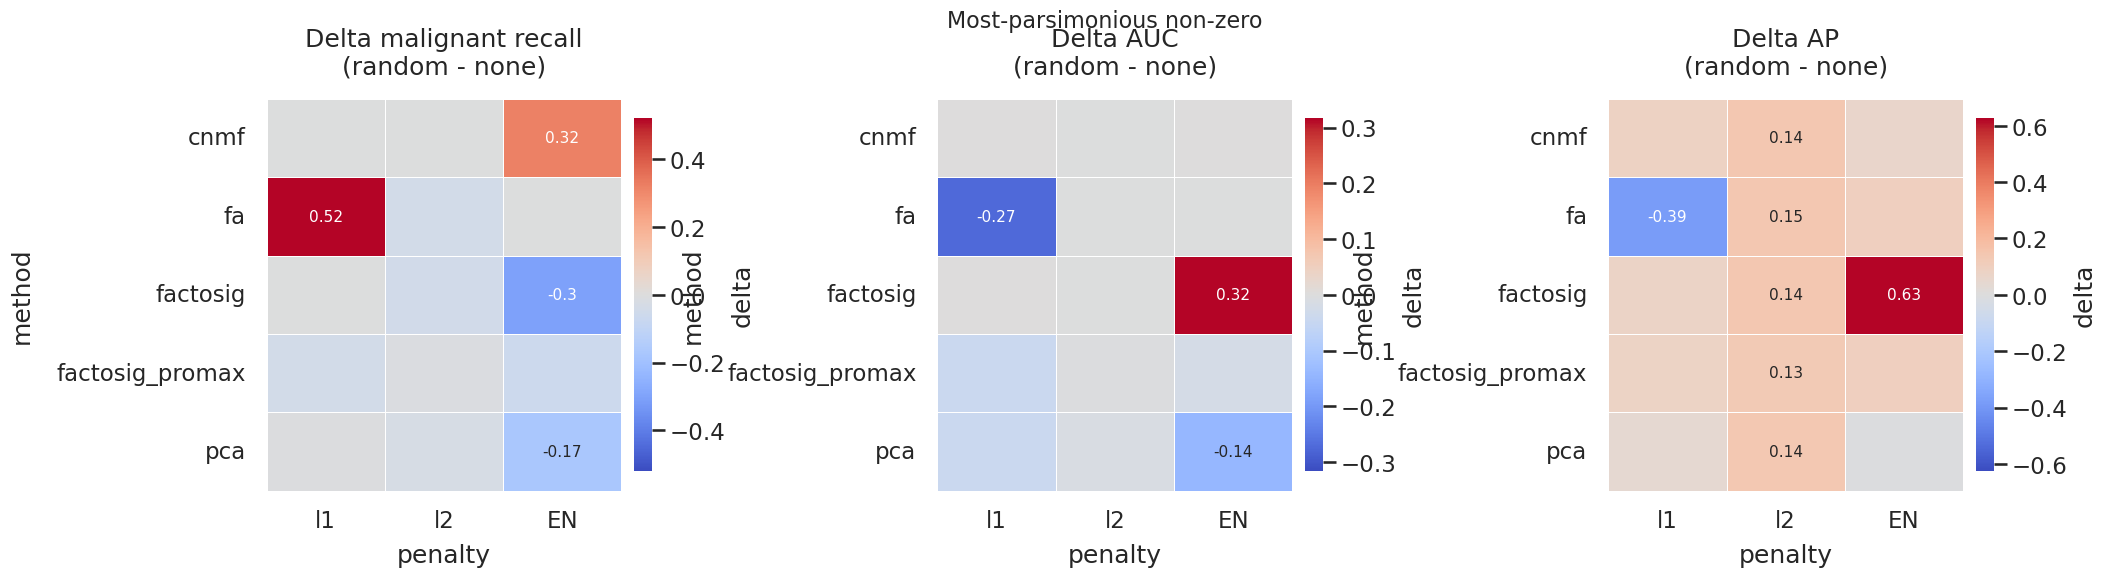

Saved downsampling report to: /home/minhang/mds_project/sc_classification/scripts/comprehensive_run/notebooks/outputs/plan1c_k40_full_reg_path_analysis_20260319/pooled_downsampling_effect_report__most_parsimonious_nonzero.csv


In [8]:
import scanpy as sc

EXP_DIR = RESULT_ROOT.parents[2]
K_FIXED = 40
SELECTION_MODE = "most_parsimonious_nonzero"
SPARSE_ZERO_ELIGIBLE_PENALTIES = {"l1", "elasticnet"}

print(f"EXP_DIR: {EXP_DIR}")
print(f"SELECTION_MODE: {SELECTION_MODE}")


def _prepare_selection_frame(metrics_df: pd.DataFrame) -> pd.DataFrame:
    d = metrics_df.copy()
    d["alpha"] = pd.to_numeric(d["alpha"], errors="coerce")
    d["C"] = pd.to_numeric(d.get("C"), errors="coerce")
    d["l1_ratio"] = pd.to_numeric(d.get("l1_ratio"), errors="coerce")
    d["mal_recall_mean"] = pd.to_numeric(d.get("mal_recall_mean"), errors="coerce").fillna(-np.inf)
    d["auc_mean"] = pd.to_numeric(d.get("auc_mean"), errors="coerce").fillna(-np.inf)
    d["ap_mean"] = pd.to_numeric(d.get("ap_mean"), errors="coerce").fillna(-np.inf)
    d["acc_mean"] = pd.to_numeric(d.get("acc_mean"), errors="coerce").fillna(-np.inf)
    d["nonzero_coef_count_full_refit"] = (
        pd.to_numeric(d.get("nonzero_coef_count_full_refit"), errors="coerce").fillna(np.inf)
    )
    return d


def _restrict_sparse_candidates_to_nonzero(
    d: pd.DataFrame,
    penalty: str,
    require_nonzero_for_sparse_penalties: bool = True,
) -> pd.DataFrame:
    if not require_nonzero_for_sparse_penalties or penalty not in SPARSE_ZERO_ELIGIBLE_PENALTIES:
        return d

    nz = d[d["nonzero_coef_count_full_refit"] > 0].copy()
    if nz.empty:
        raise ValueError(
            f"No non-zero candidate models remain for penalty={penalty}. "
            "Check whether the full path is entirely collapsed to zero."
        )
    return nz


def select_model_row(
    metrics_df: pd.DataFrame,
    penalty: str,
    selection_mode: str = "most_parsimonious_nonzero",
    recall_delta: float = 0.01,
    auc_delta: float = 0.005,
    ap_delta: float = 0.01,
    require_nonzero_for_sparse_penalties: bool = True,
) -> pd.Series:
    """Select a single row from the CV summary table.

    Supported modes:
    - ``most_parsimonious_nonzero``: for sparse penalties, exclude all-zero rows first,
      then choose the strongest regularization (largest alpha); tie-break by recall, AUC,
      AP, then fewer nonzero factors.
    - ``recall_first_nonzero``: future-facing option that preserves the earlier recall-first
      filtering but still excludes all-zero sparse solutions before tie-breaking by sparsity.
    """
    d = _prepare_selection_frame(metrics_df)
    d = _restrict_sparse_candidates_to_nonzero(
        d,
        penalty=penalty,
        require_nonzero_for_sparse_penalties=require_nonzero_for_sparse_penalties,
    )

    if selection_mode == "most_parsimonious_nonzero":
        max_alpha = d["alpha"].max()
        d = d[np.isclose(d["alpha"], max_alpha, atol=1e-12)].copy()
        d = d.sort_values(
            ["mal_recall_mean", "auc_mean", "ap_mean", "nonzero_coef_count_full_refit"],
            ascending=[False, False, False, True],
        )
        return d.iloc[0]

    if selection_mode == "recall_first_nonzero":
        best_recall = d["mal_recall_mean"].max()
        d1 = d[d["mal_recall_mean"] >= (best_recall - recall_delta)]

        best_auc = d1["auc_mean"].max()
        d2 = d1[d1["auc_mean"] >= (best_auc - auc_delta)]

        best_ap = d2["ap_mean"].max()
        d3 = d2[d2["ap_mean"] >= (best_ap - ap_delta)]

        d3 = d3.sort_values(
            ["nonzero_coef_count_full_refit", "alpha"],
            ascending=[True, False],
        )
        return d3.iloc[0]

    raise ValueError(f"Unsupported selection_mode: {selection_mode}")


def build_pooled_selection_table(
    pooled_idx: pd.DataFrame,
    selection_mode: str = "most_parsimonious_nonzero",
) -> pd.DataFrame:
    rows = []
    for _, run_row in pooled_idx.sort_values(["method", "downsampling", "penalty"]).iterrows():
        _, metrics_df = load_pair(run_row)
        chosen = select_model_row(
            metrics_df,
            penalty=run_row.penalty,
            selection_mode=selection_mode,
        )
        class_counts = get_class_counts_from_oof(run_row) or {"malignant": np.nan, "healthy": np.nan}

        strongest_alpha = float(pd.to_numeric(metrics_df["alpha"], errors="coerce").max())
        strongest_rows = metrics_df[np.isclose(pd.to_numeric(metrics_df["alpha"], errors="coerce"), strongest_alpha, atol=1e-12)].copy()
        strongest_nz = pd.to_numeric(strongest_rows.get("nonzero_coef_count_full_refit"), errors="coerce")
        strongest_alpha_has_any_nonzero = bool((strongest_nz.fillna(0) > 0).any())

        rows.append(
            {
                "method": run_row.method,
                "downsampling": run_row.downsampling,
                "downsampling_display": pretty_downsampling(run_row.downsampling),
                "penalty": run_row.penalty,
                "selection_mode": selection_mode,
                "selected_alpha": float(chosen["alpha"]),
                "selected_C": float(chosen["C"]),
                "selected_l1_ratio": float(chosen["l1_ratio"]) if pd.notna(chosen.get("l1_ratio", np.nan)) else np.nan,
                "auc_mean": float(chosen["auc_mean"]),
                "auc_std": float(chosen["auc_std"]) if "auc_std" in chosen else np.nan,
                "ap_mean": float(chosen["ap_mean"]),
                "ap_std": float(chosen["ap_std"]) if "ap_std" in chosen else np.nan,
                "acc_mean": float(chosen["acc_mean"]),
                "acc_std": float(chosen["acc_std"]) if "acc_std" in chosen else np.nan,
                "mal_recall_mean": float(chosen["mal_recall_mean"]),
                "mal_recall_std": float(chosen["mal_recall_std"]) if "mal_recall_std" in chosen else np.nan,
                "nonzero_coef_count_full_refit": float(chosen["nonzero_coef_count_full_refit"]),
                "strongest_alpha": strongest_alpha,
                "strongest_alpha_has_any_nonzero": strongest_alpha_has_any_nonzero,
                "malignant_cells": class_counts["malignant"],
                "healthy_cells": class_counts["healthy"],
                "coef_path": run_row.coef_path,
                "metrics_path": run_row.metrics_path,
            }
        )

    return pd.DataFrame(rows)


def build_downsampling_effect_report(selected_df: pd.DataFrame) -> pd.DataFrame:
    none_df = selected_df[selected_df["downsampling"] == "none"].copy()
    rand_df = selected_df[selected_df["downsampling"] == "random"].copy()

    # use the ["method", "penalty", "selection_mode"] columns to merge the two dataframes
    cmp = none_df.merge(
        rand_df,
        on=["method", "penalty", "selection_mode"],
        suffixes=("_none", "_random"),
    )

    # from the merged dataframe, compute the difference in performance between the 
    # two downsampling methods using average performance across all patients
    for metric in [
        "mal_recall_mean",
        "auc_mean",
        "ap_mean",
        "acc_mean",
        "nonzero_coef_count_full_refit",
    ]:
        cmp[f"delta_{metric}"] = cmp[f"{metric}_random"] - cmp[f"{metric}_none"]

    return cmp


def plot_downsampling_effect_heatmaps(
    cmp: pd.DataFrame,
    title_prefix: str = "",
    annotation_abs_threshold: float = 0.1,
):
    penalty_order = ["l1", "l2", "elasticnet"]
    penalty_display = {"l1": "l1", "l2": "l2", "elasticnet": "EN"}
    method_order = sorted(cmp["method"].unique().tolist())

    def _pivot(col: str) -> pd.DataFrame:
        p = cmp.pivot(index="method", columns="penalty", values=col)
        return p.reindex(index=method_order, columns=penalty_order)

    def _format_annotation(v: float) -> str:
        if pd.isna(v) or abs(v) < annotation_abs_threshold:
            return ""
        return f"{v:.2g}"

    mats = [
        ("delta_mal_recall_mean", "Delta malignant recall\n(random - none)"),
        ("delta_auc_mean", "Delta AUC\n(random - none)"),
        ("delta_ap_mean", "Delta AP\n(random - none)"),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(19.5, 5.6))
    fig.subplots_adjust(
        wspace=0.55,
        top=0.82 if title_prefix else 0.9,
        left=0.07,
        right=0.98,
        bottom=0.12,
    )

    for ax, (col, ttl) in zip(axes, mats):
        p = _pivot(col)
        annot = p.applymap(_format_annotation)
        vmax = np.nanmax(np.abs(p.values))
        vmax = float(vmax) if np.isfinite(vmax) and vmax > 0 else 1e-6
        sns.heatmap(
            p,
            annot=annot,
            fmt="",
            annot_kws={"fontsize": 11},
            cmap="coolwarm",
            center=0,
            vmin=-vmax,
            vmax=vmax,
            linewidths=0.5,
            linecolor="white",
            cbar_kws={"label": "delta", "shrink": 0.9, "pad": 0.03},
            ax=ax,
        )
        ax.set_title(ttl, pad=18)
        ax.set_xlabel("penalty", labelpad=8)
        ax.set_ylabel("method", labelpad=16)
        ax.tick_params(axis="x", pad=4)
        ax.tick_params(axis="y", pad=6, rotation=0)
        ax.set_xticklabels([penalty_display.get(t.get_text(), t.get_text()) for t in ax.get_xticklabels()])

    if title_prefix:
        fig.suptitle(title_prefix, fontsize=16, y=0.98)

    plt.show()


pooled_selected = build_pooled_selection_table(pooled_index, selection_mode=SELECTION_MODE)

display(
    pooled_selected[
        [
            "method",
            "downsampling_display",
            "penalty",
            "selected_alpha",
            "selected_l1_ratio",
            "mal_recall_mean",
            "auc_mean",
            "ap_mean",
            "nonzero_coef_count_full_refit",
            "strongest_alpha_has_any_nonzero",
        ]
    ]
    .sort_values(["method", "downsampling_display", "penalty"])
    .reset_index(drop=True)
)

print("Selected nonzero-factor counts:")
display(pooled_selected["nonzero_coef_count_full_refit"].value_counts().sort_index())

print("Sparse-penalty diagnostic summary:")
display(
    pooled_selected[
        pooled_selected["penalty"].isin(sorted(SPARSE_ZERO_ELIGIBLE_PENALTIES))
    ][
        [
            "method",
            "downsampling_display",
            "penalty",
            "selected_alpha",
            "selected_l1_ratio",
            "nonzero_coef_count_full_refit",
            "strongest_alpha",
            "strongest_alpha_has_any_nonzero",
        ]
    ]
    .sort_values(["penalty", "method", "downsampling_display"])
    .reset_index(drop=True)
)

pooled_selected.to_csv(
    OUTPUT_DIR / f"pooled_selected_models__{SELECTION_MODE}.csv",
    index=False,
)
print(f"Saved selection table to: {OUTPUT_DIR / f'pooled_selected_models__{SELECTION_MODE}.csv'}")

# using build_downsampling_effect_report to generate the downsampling effect report
cmp = build_downsampling_effect_report(pooled_selected)
downsampling_report_cols = [
    "method",
    "penalty",
    "selected_alpha_none",
    "selected_alpha_random",
    "selected_l1_ratio_none",
    "selected_l1_ratio_random",
    "delta_mal_recall_mean",
    "delta_auc_mean",
    "delta_ap_mean",
    "delta_acc_mean",
    "delta_nonzero_coef_count_full_refit",
]

display(cmp[downsampling_report_cols].sort_values(["method", "penalty"]).reset_index(drop=True))
plot_downsampling_effect_heatmaps(cmp, title_prefix="Most-parsimonious non-zero")
cmp.to_csv(
    OUTPUT_DIR / f"pooled_downsampling_effect_report__{SELECTION_MODE}.csv",
    index=False,
)
print(f"Saved downsampling report to: {OUTPUT_DIR / f'pooled_downsampling_effect_report__{SELECTION_MODE}.csv'}")

Signature matrix shape (genes x selected models): (10000, 30)


,cnmf|none|elasticnet,cnmf|none|l1,cnmf|none|l2,cnmf|random|elasticnet,cnmf|random|l1
A2M,0.000039,0.000341,3.657687e-05,0.000010,0.000269
A4GALT,0.000000,0.000000,-1.387056e-05,0.000000,0.000000
A4GNT,0.000000,0.000000,0.000000e+00,0.000000,0.000000
AADACL2,0.000000,0.000000,0.000000e+00,0.000000,0.000000
AADACL2-AS1,0.000014,0.000123,1.880128e-07,0.000004,0.000097


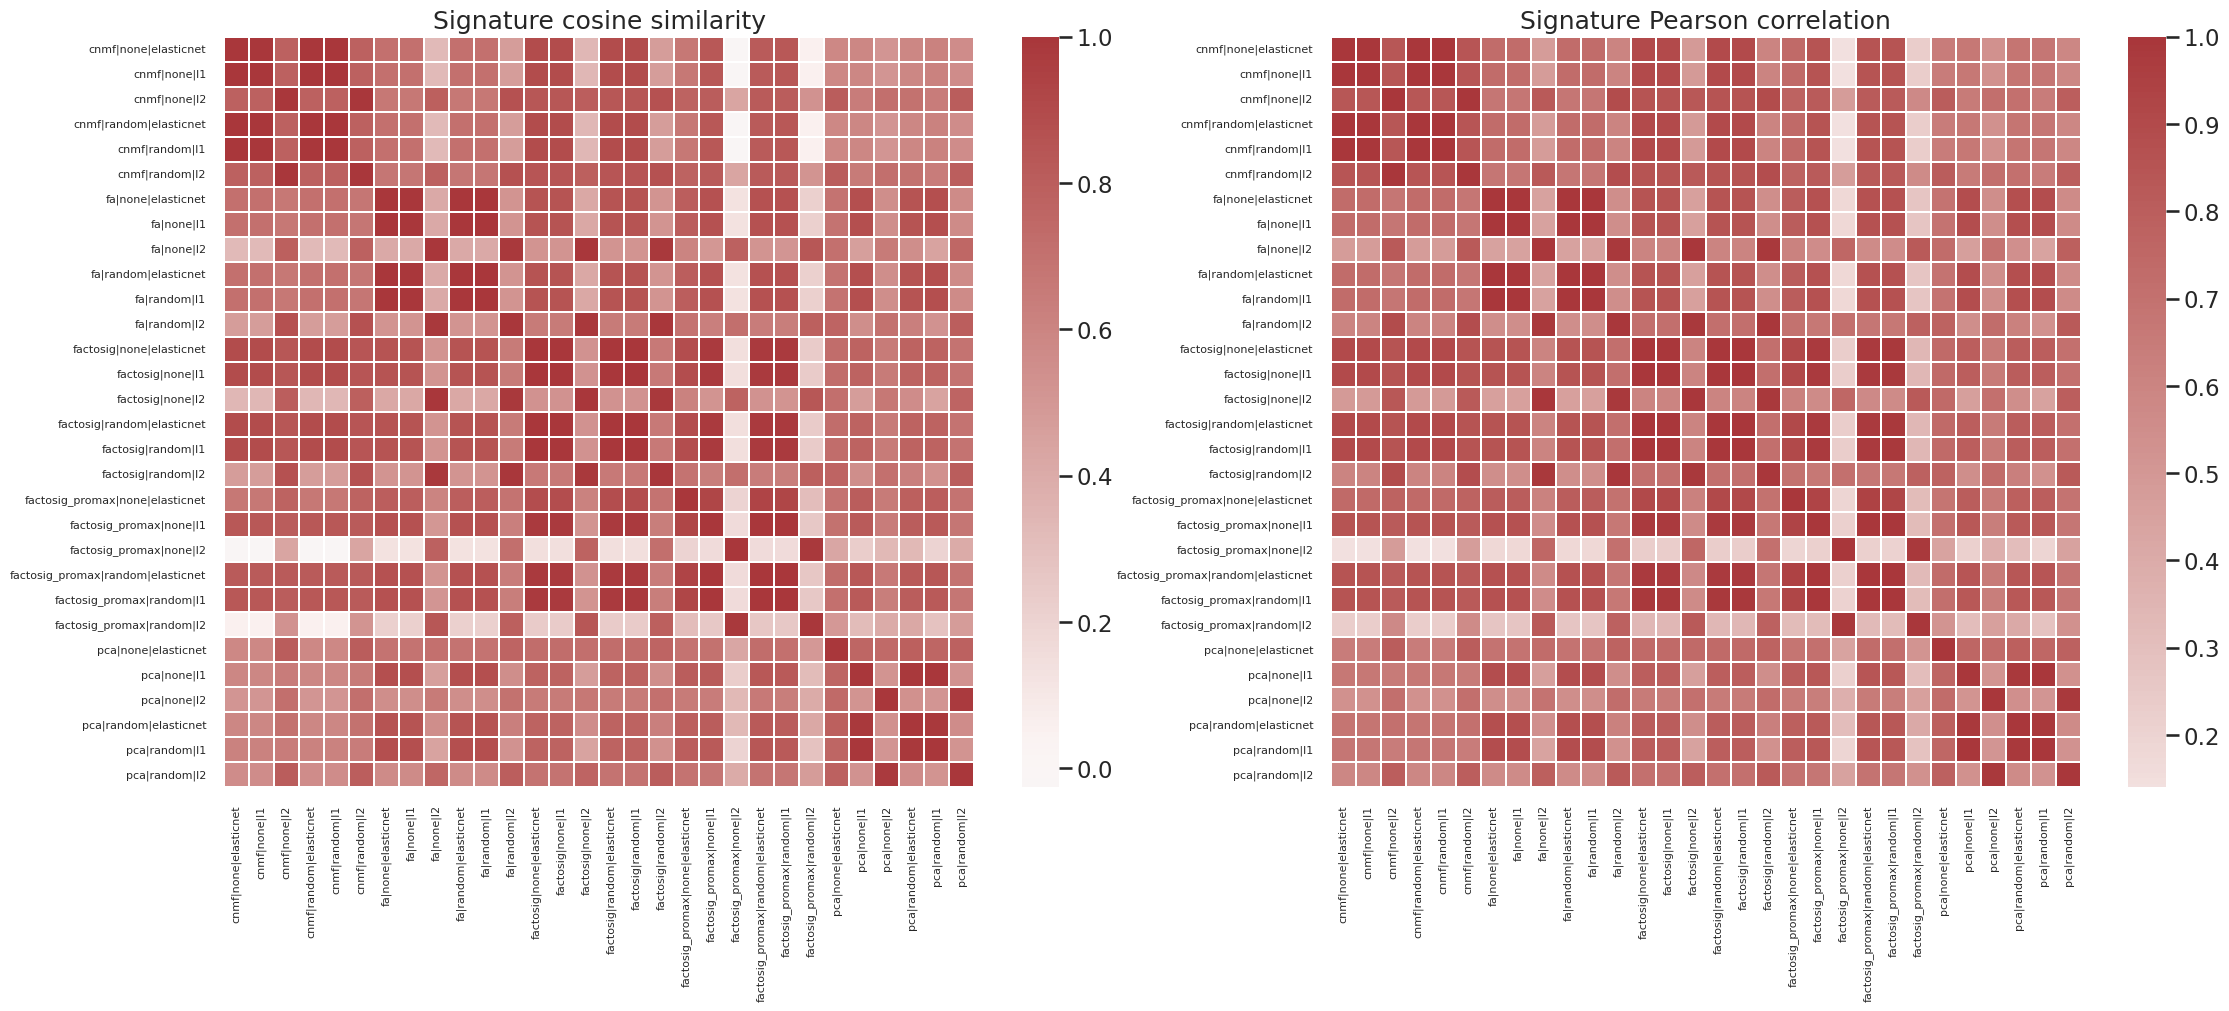

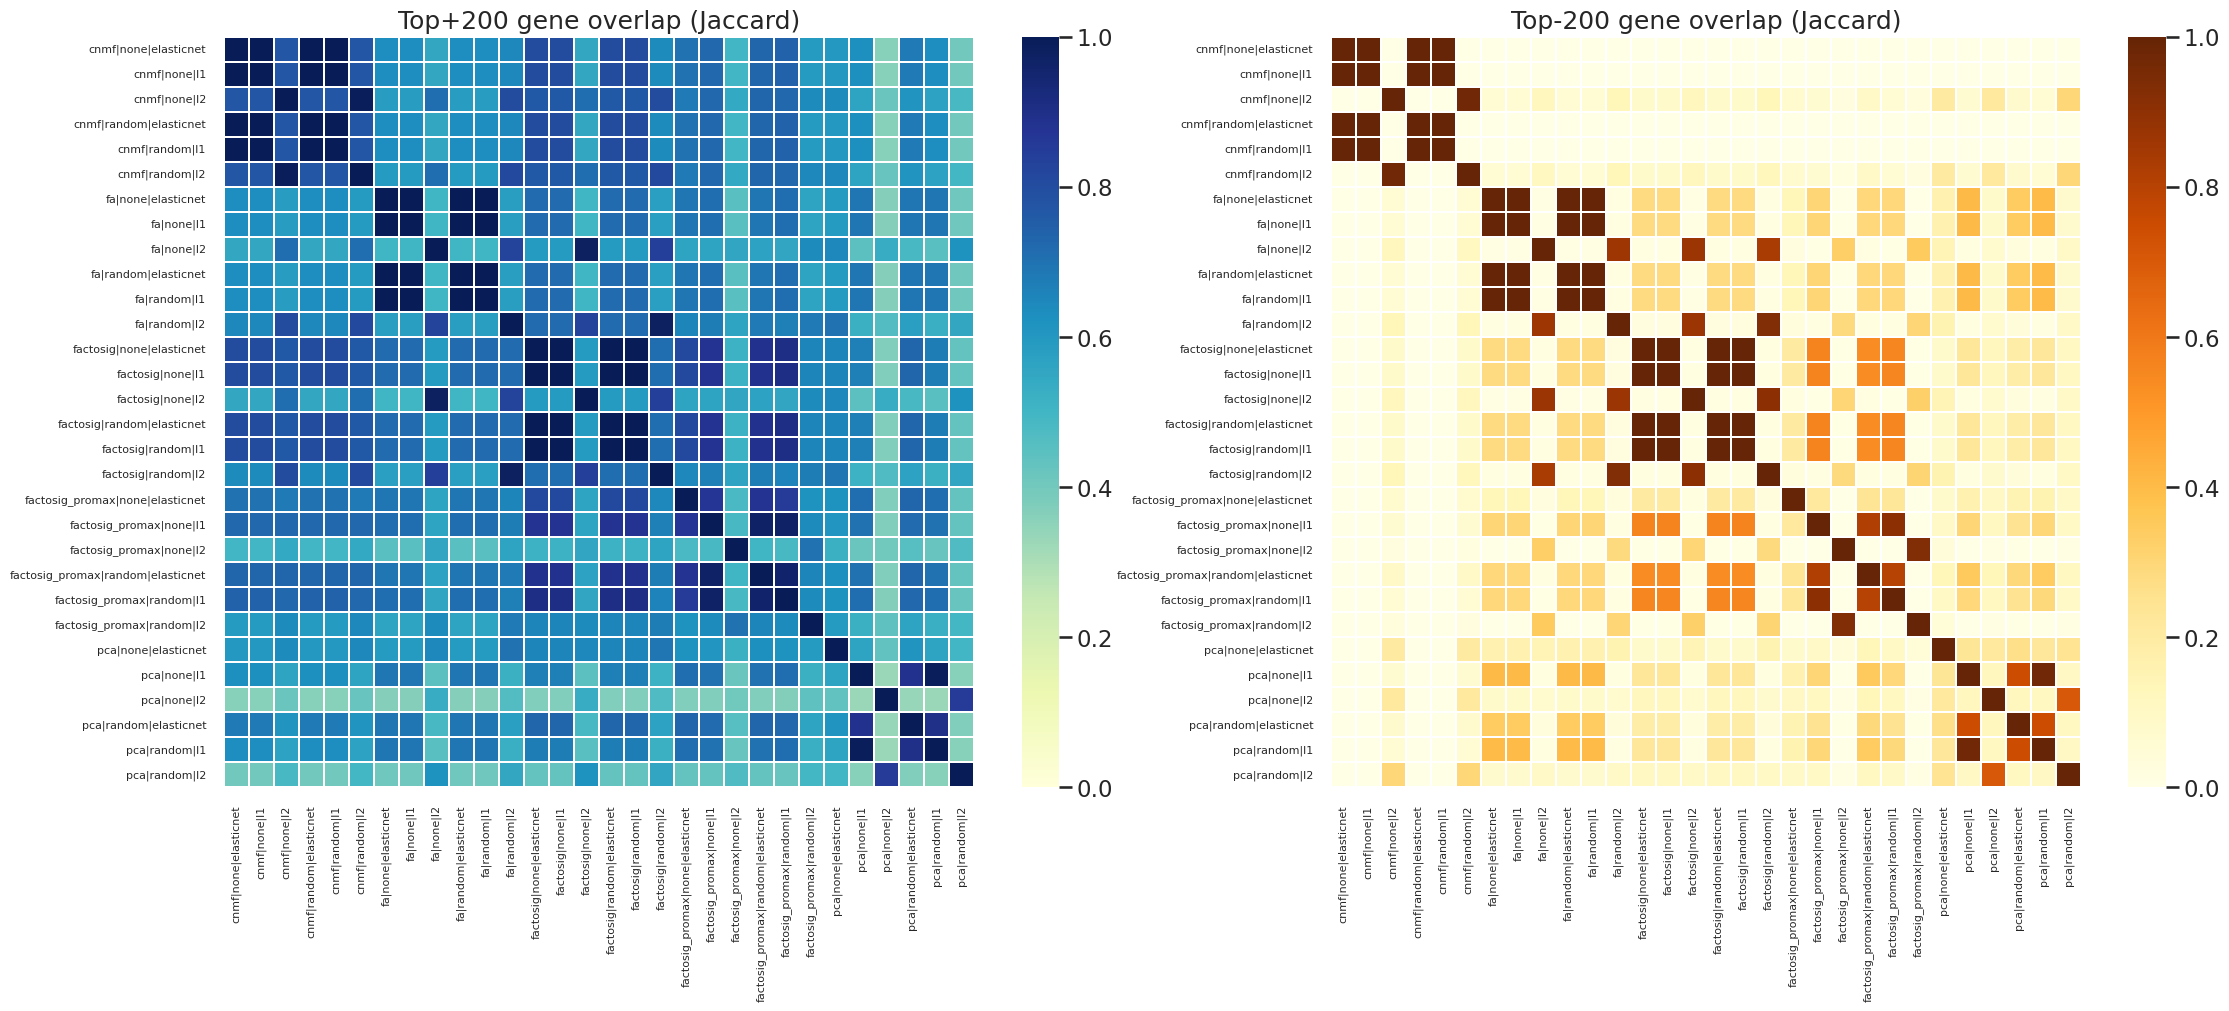

Saved signature matrix, similarity matrices, and overlap tables to OUTPUT_DIR


In [9]:
def load_df_npz(path: Path) -> pd.DataFrame:
    z = np.load(path, allow_pickle=True)
    return pd.DataFrame(z["data"], index=z["index"], columns=z["columns"])


def get_gene_names(exp_dir: Path) -> pd.Index:
    ad = sc.read_h5ad(exp_dir / "preprocessing" / "adata_processed.h5ad", backed="r")
    genes = ad.var_names.copy()
    del ad
    return genes


def load_gene_loadings(exp_dir: Path, method: str, k: int = 40) -> pd.DataFrame:
    genes = get_gene_names(exp_dir)

    if method in {"fa", "factosig"}:
        adk = sc.read_h5ad(exp_dir / "preprocessing" / f"adata_processed_with_plan0_dr_k{k}_seed1.h5ad", backed="r")
        key = "FA_loadings" if method == "fa" else "FACTOSIG_loadings"
        L = np.asarray(adk.varm[key])
        cols = [f"{method}_{i+1}" for i in range(L.shape[1])]
        out = pd.DataFrame(L, index=genes, columns=cols)
        del adk
        return out

    if method in {"pca", "factosig_promax"}:
        p = exp_dir / "analysis" / "plan0" / "stability" / method / f"k_{k}" / "replicates" / "seed_1" / "loadings.npy"
        L = np.load(p)
        cols = [f"{method}_{i+1}" for i in range(L.shape[1])]
        return pd.DataFrame(L, index=genes, columns=cols)

    if method == "cnmf":
        p = exp_dir / "models" / "cnmf_plan0" / "curated" / f"k_{k}" / "consensus" / f"plan0_cnmf.spectra.k_{k}.dt_0_5.consensus.df.npz"
        S = load_df_npz(p)
        L = S.T.copy()
        L.columns = L.columns.astype(str)
        return L

    raise ValueError(f"Unsupported method: {method}")


def coef_vector_at_selected_point(coef_df: pd.DataFrame, alpha: float, l1_ratio: float | None) -> pd.Series:
    c = coef_df.copy()
    c = c[np.isclose(c["alpha"], alpha, atol=1e-12)]

    if "l1_ratio" in c.columns:
        if pd.isna(l1_ratio):
            c = c[c["l1_ratio"].isna()]
        else:
            c = c[np.isclose(c["l1_ratio"], l1_ratio, atol=1e-12)]

    if c.empty:
        raise ValueError("No coefficient rows found for selected alpha/l1_ratio.")

    w = c.groupby("feature", observed=False)["coef"].mean()
    w.index = w.index.astype(str)
    return w


def build_selected_signatures(selected_df: pd.DataFrame, exp_dir: Path, k: int = 40) -> pd.DataFrame:
    method_loadings: dict[str, pd.DataFrame] = {}
    signatures = {}

    for _, r in selected_df.iterrows():
        method = r["method"]
        if method not in method_loadings:
            method_loadings[method] = load_gene_loadings(exp_dir, method, k=k)

        L = method_loadings[method].copy()
        L.columns = L.columns.astype(str)

        coef_df = pd.read_csv(r["coef_path"])
        w = coef_vector_at_selected_point(
            coef_df,
            alpha=r["selected_alpha"],
            l1_ratio=r["selected_l1_ratio"],
        )
        w = w.reindex(L.columns).fillna(0.0)

        s = L.values @ w.values
        model_id = f"{method}|{r['downsampling']}|{r['penalty']}"
        signatures[model_id] = pd.Series(s, index=L.index)

    return pd.DataFrame(signatures)


def cosine_similarity_matrix(X: pd.DataFrame) -> pd.DataFrame:
    A = X.values
    denom = np.linalg.norm(A, axis=0, keepdims=True)
    denom[denom == 0] = 1.0
    A_norm = A / denom
    sim = A_norm.T @ A_norm
    return pd.DataFrame(sim, index=X.columns, columns=X.columns)


def jaccard_matrix(sets_by_name: dict[str, set]) -> pd.DataFrame:
    names = list(sets_by_name.keys())
    out = pd.DataFrame(index=names, columns=names, dtype=float)
    for a in names:
        for b in names:
            A, B = sets_by_name[a], sets_by_name[b]
            union_size = len(A | B)
            out.loc[a, b] = len(A & B) / union_size if union_size > 0 else np.nan
    return out


def style_dense_heatmap_axis(ax, xsize: int = 8, ysize: int = 8):
    ax.tick_params(axis="x", labelrotation=90, labelsize=xsize)
    ax.tick_params(axis="y", labelrotation=0, labelsize=ysize)


sig_df = build_selected_signatures(pooled_selected, EXP_DIR, k=K_FIXED)
print("Signature matrix shape (genes x selected models):", sig_df.shape)
display(sig_df.iloc[:5, :5])

cos_sim = cosine_similarity_matrix(sig_df)
pearson_sim = sig_df.corr(method="pearson")

fig, axes = plt.subplots(1, 2, figsize=(22, 10), constrained_layout=True)
sns.heatmap(
    cos_sim,
    cmap="vlag",
    center=0,
    square=True,
    linewidths=0.2,
    linecolor="white",
    xticklabels=1,
    yticklabels=1,
    ax=axes[0],
)
axes[0].set_title("Signature cosine similarity")
style_dense_heatmap_axis(axes[0])

sns.heatmap(
    pearson_sim,
    cmap="vlag",
    center=0,
    square=True,
    linewidths=0.2,
    linecolor="white",
    xticklabels=1,
    yticklabels=1,
    ax=axes[1],
)
axes[1].set_title("Signature Pearson correlation")
style_dense_heatmap_axis(axes[1])
plt.show()

TOP_N = 200
pos_sets = {name: set(sig_df[name].nlargest(TOP_N).index.astype(str)) for name in sig_df.columns}
neg_sets = {name: set(sig_df[name].nsmallest(TOP_N).index.astype(str)) for name in sig_df.columns}

pos_j = jaccard_matrix(pos_sets)
neg_j = jaccard_matrix(neg_sets)

fig, axes = plt.subplots(1, 2, figsize=(22, 10), constrained_layout=True)
sns.heatmap(
    pos_j,
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    square=True,
    linewidths=0.2,
    linecolor="white",
    xticklabels=1,
    yticklabels=1,
    ax=axes[0],
)
axes[0].set_title(f"Top+{TOP_N} gene overlap (Jaccard)")
style_dense_heatmap_axis(axes[0])

sns.heatmap(
    neg_j,
    cmap="YlOrBr",
    vmin=0,
    vmax=1,
    square=True,
    linewidths=0.2,
    linecolor="white",
    xticklabels=1,
    yticklabels=1,
    ax=axes[1],
)
axes[1].set_title(f"Top-{TOP_N} gene overlap (Jaccard)")
style_dense_heatmap_axis(axes[1])
plt.show()

sig_df.to_csv(OUTPUT_DIR / f"pooled_selected_signature_matrix__{SELECTION_MODE}.csv")
cos_sim.to_csv(OUTPUT_DIR / f"pooled_selected_signature_cosine_similarity__{SELECTION_MODE}.csv")
pearson_sim.to_csv(OUTPUT_DIR / f"pooled_selected_signature_pearson_similarity__{SELECTION_MODE}.csv")
pos_j.to_csv(OUTPUT_DIR / f"pooled_selected_top{TOP_N}_positive_gene_jaccard__{SELECTION_MODE}.csv")
neg_j.to_csv(OUTPUT_DIR / f"pooled_selected_top{TOP_N}_negative_gene_jaccard__{SELECTION_MODE}.csv")
print("Saved signature matrix, similarity matrices, and overlap tables to OUTPUT_DIR")

In [21]:
print(f'HUCIRA_FOCUS_TERMS: {HUCIRA_FOCUS_TERMS}')

HUCIRA_FOCUS_TERMS: ['IFN', 'TNF', 'IL1', 'IL10', 'IL15', 'IL32', 'Antigen', 'Myeloid']


,model_uid,rank,program_name,cosine_similarity
0,cnmf|none|elasticnet,1,IFN-epsilon,0.063107
1,cnmf|none|elasticnet,2,TNF-alpha,0.033323
2,cnmf|none|elasticnet,3,IFN-lambda2,0.027190
3,cnmf|none|elasticnet,4,IFN-lambda1,0.017240
4,cnmf|none|elasticnet,5,IFN-alpha1,-0.049792
...,...,...,...,...
145,pca|random|l2,1,IFN-epsilon,0.045499
146,pca|random|l2,2,IFN-lambda1,0.030060
147,pca|random|l2,3,IFN-alpha1,0.025801
148,pca|random|l2,4,IFN-lambda3,0.009099


,model_uid,rank,program_name,cosine_similarity
0,cnmf|none|elasticnet,1,II-04 MyeloidActive,0.145433
1,cnmf|none|elasticnet,2,CS-08 MyeloidRemodel,0.133985
2,cnmf|none|elasticnet,3,II-20 MyeloidMetab,0.128158
3,cnmf|none|elasticnet,4,II-29 MyeloidLipid,0.112740
4,cnmf|none|elasticnet,5,MD-03 AntigenProc,0.103132
...,...,...,...,...
145,pca|random|l2,1,II-29 MyeloidLipid,0.076111
146,pca|random|l2,2,CS-08 MyeloidRemodel,0.037450
147,pca|random|l2,3,II-20 MyeloidMetab,-0.002066
148,pca|random|l2,4,II-25 IFN-Induction,-0.002427


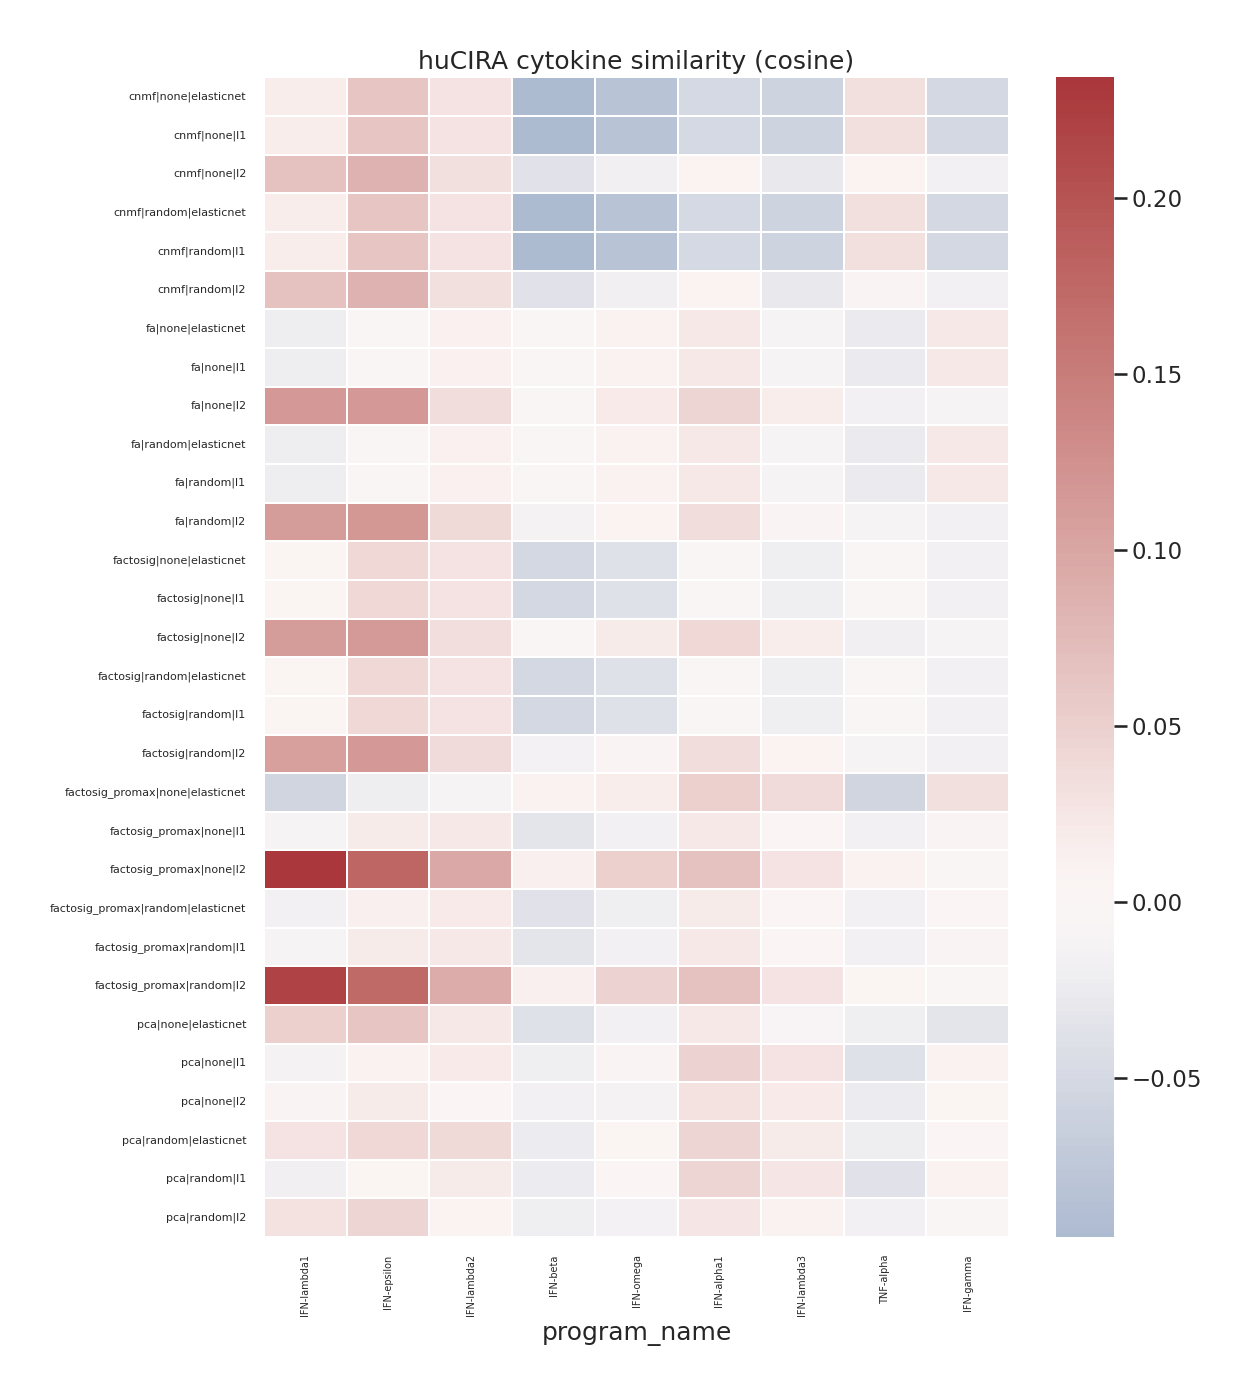

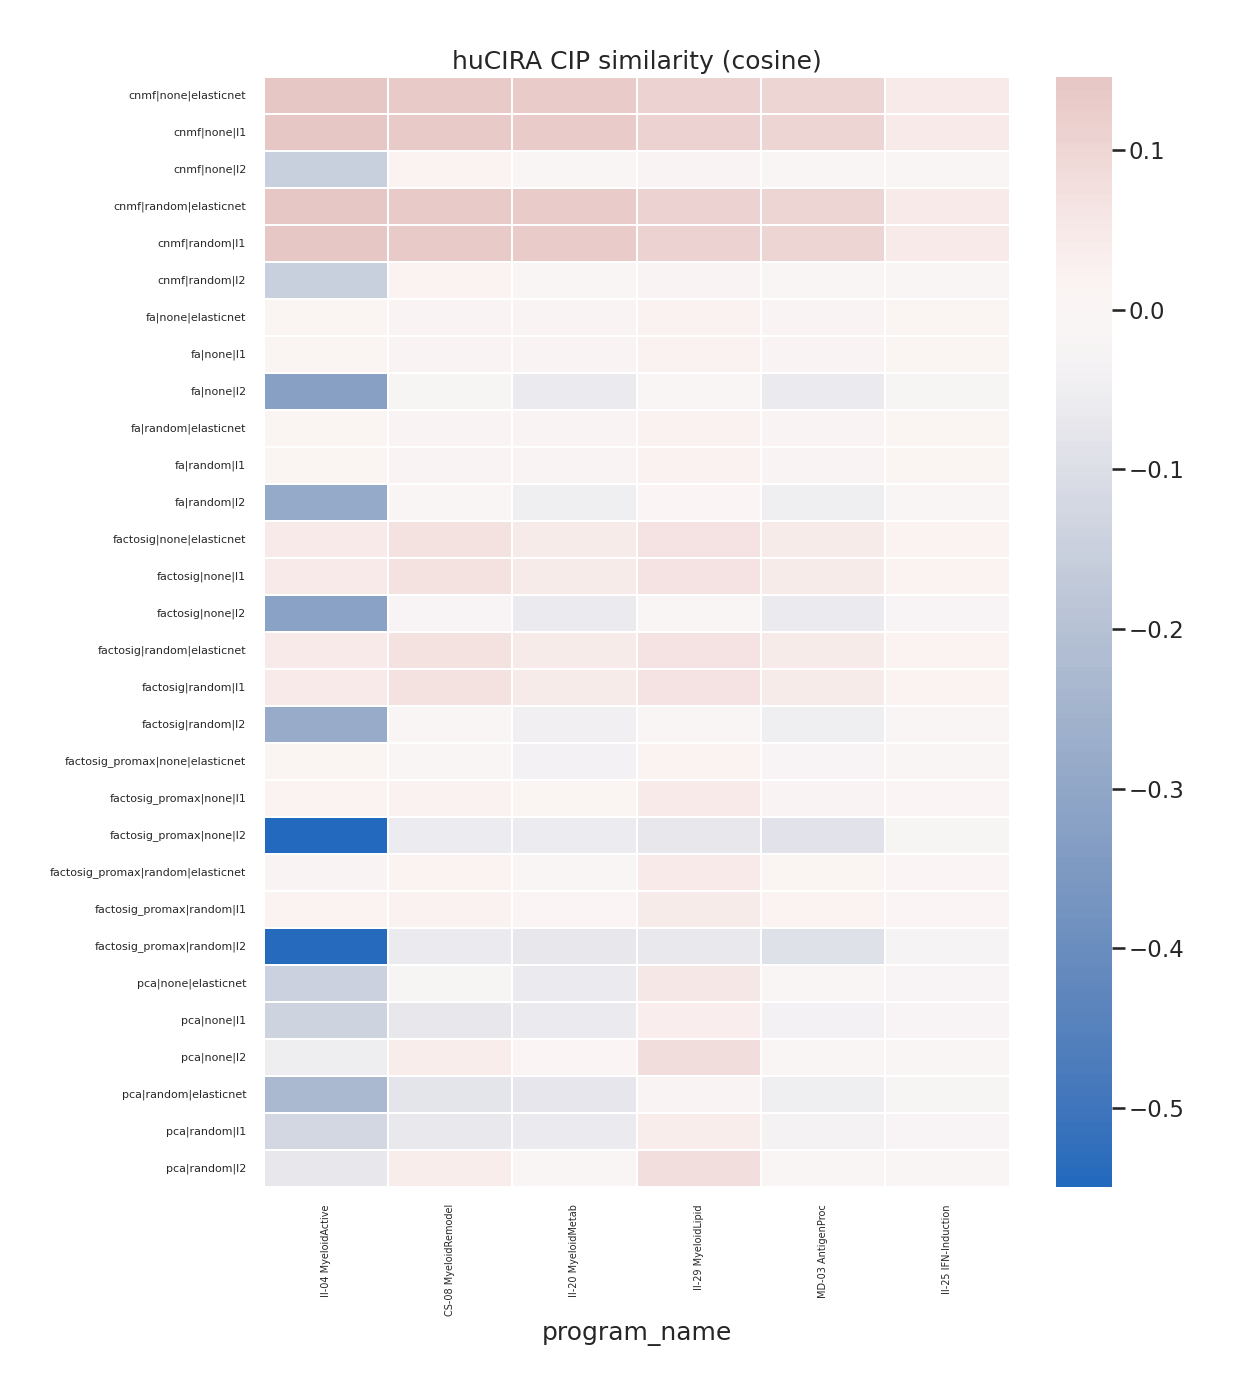

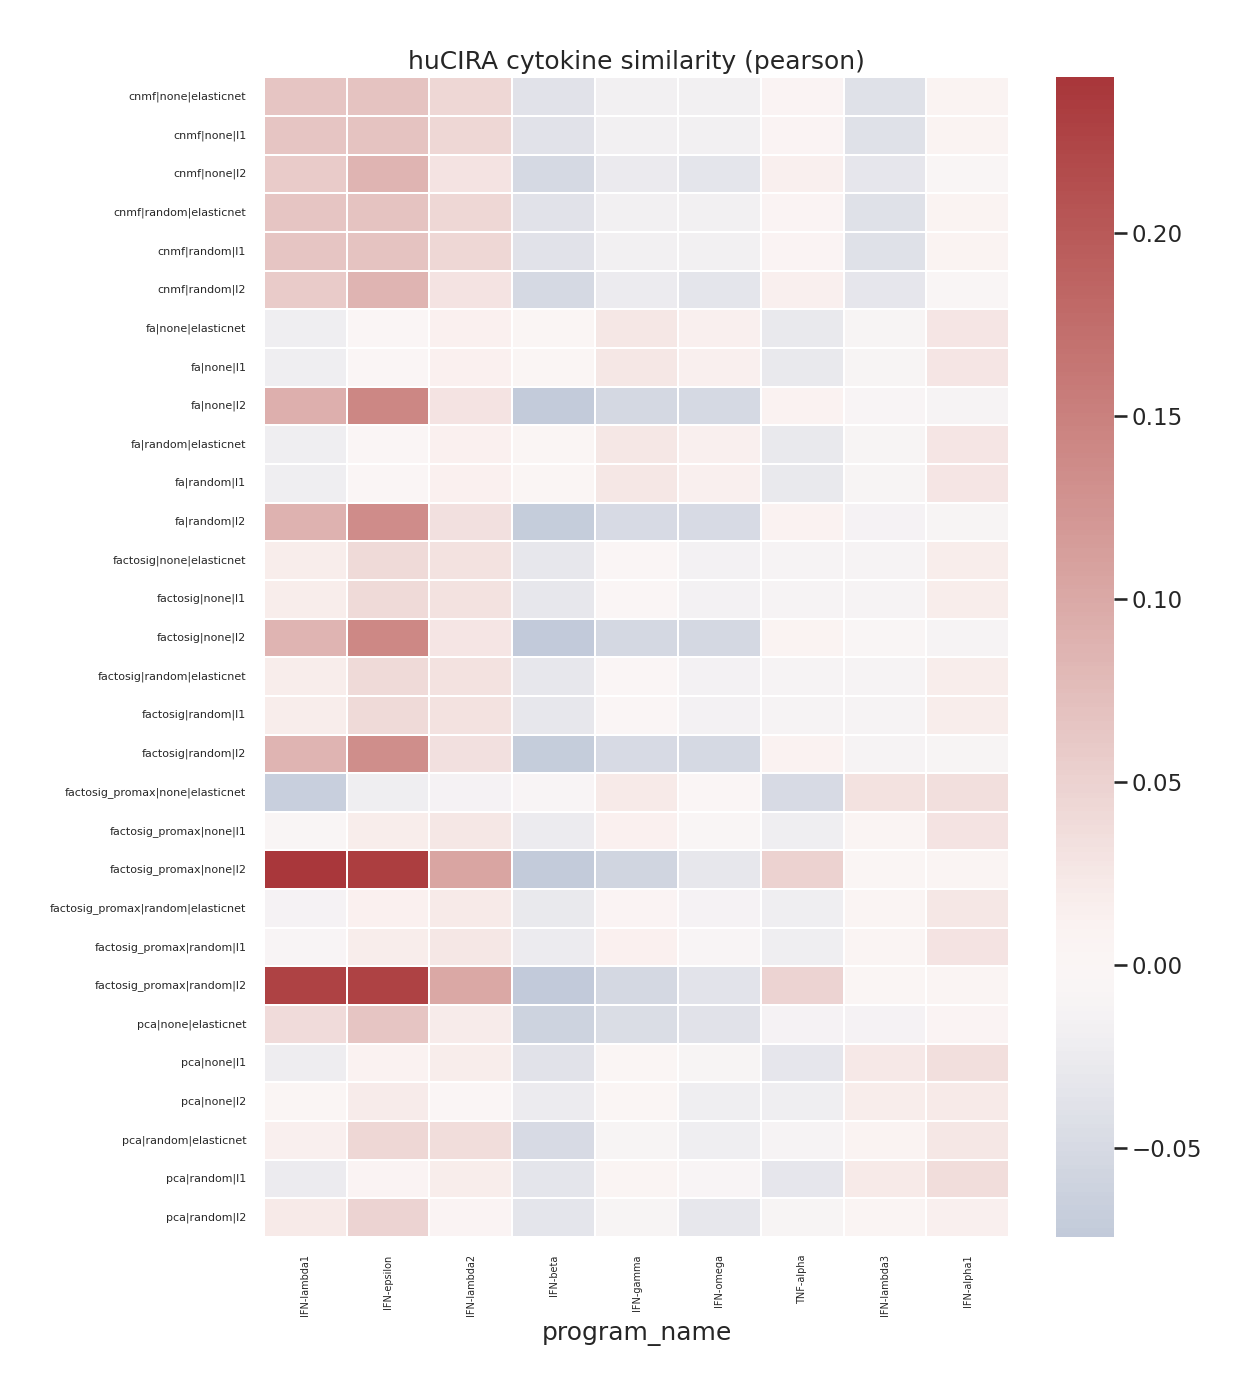

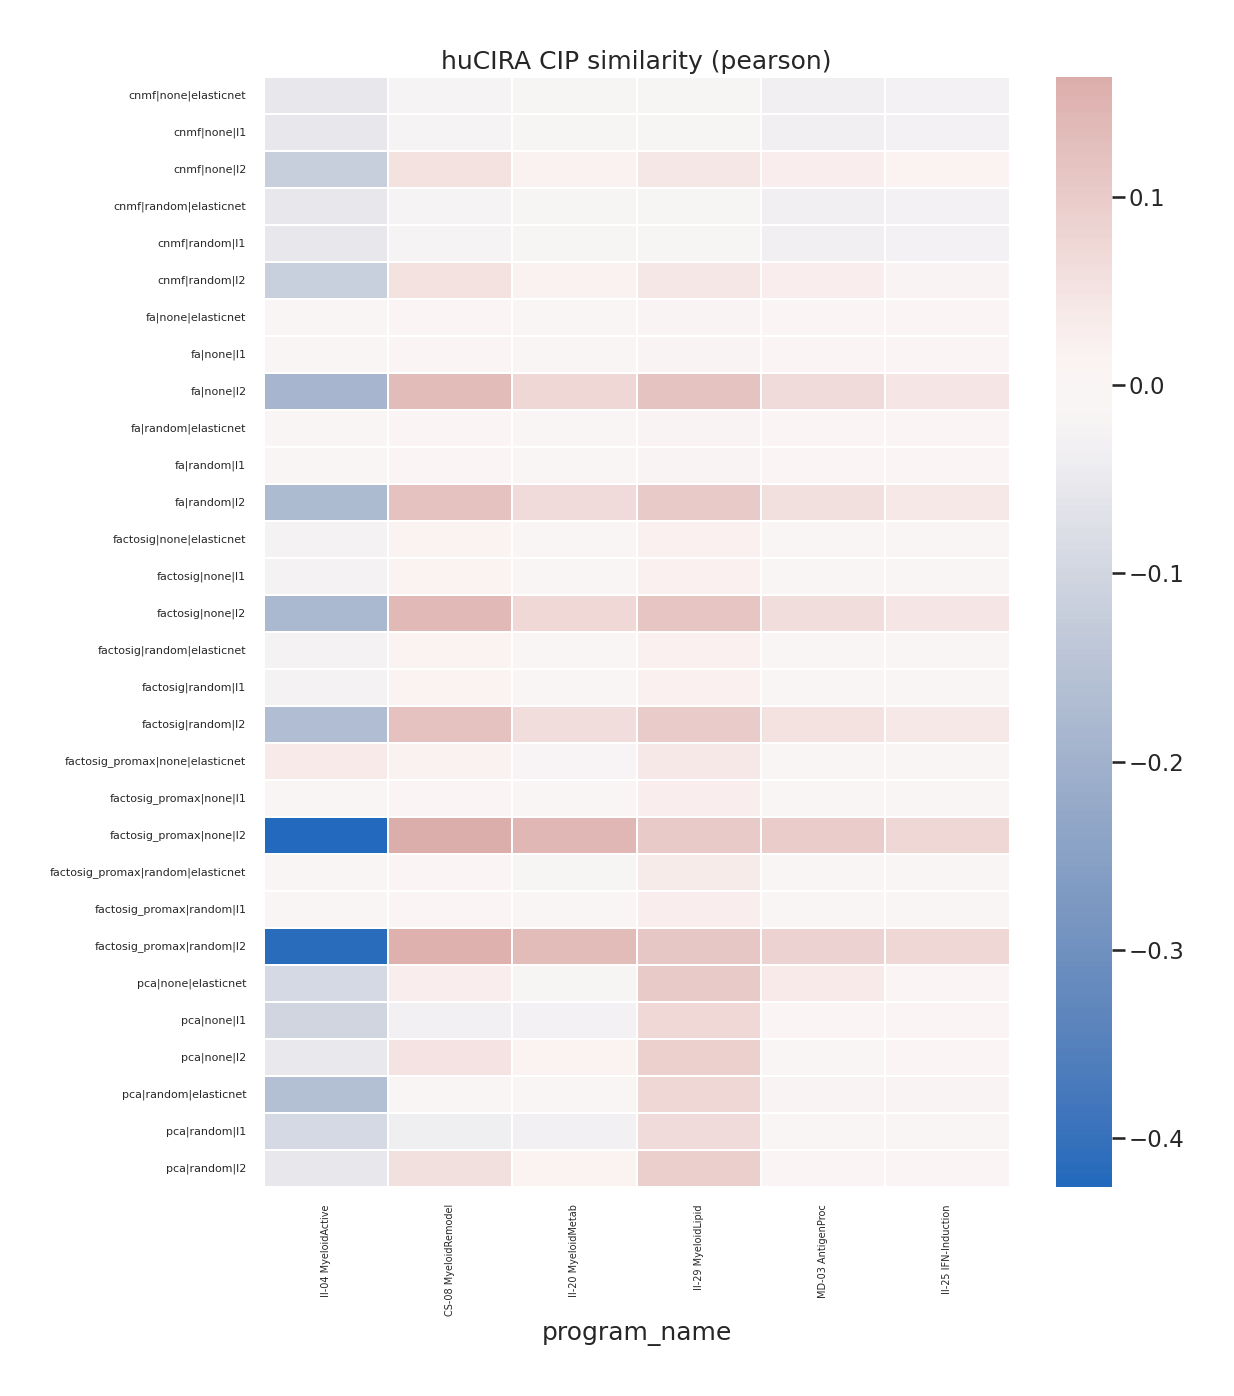

Saved huCIRA pooled interpretation outputs to: /home/minhang/mds_project/sc_classification/scripts/comprehensive_run/notebooks/outputs/plan1c_k40_full_reg_path_analysis_20260319/predictive_signature_hucira_similarity__most_parsimonious_nonzero


In [22]:
# huCIRA projection of pooled predictive signatures
from sc_classification.utils.hucira_interpretation import (
    DEFAULT_HUCIRA_PROGRAM_SUBSET,
    compute_signature_program_jaccard,
    compute_signature_program_similarity,
    export_hucira_reference_sets,
    load_hucira_reference_assets,
    select_reference_programs,
    summarize_top_program_matches,
)

HUCIRA_REFERENCE_DIR = Path("/home/minhang/mds_project/data/hucira_reference")
HUCIRA_AUTO_BUILD = False
HUCIRA_FOCUS_TERMS = DEFAULT_HUCIRA_PROGRAM_SUBSET
HUCIRA_TOP_K_MATCHES = 5
HUCIRA_TOP_HEATMAP_PROGRAMS = 40
HUCIRA_TOP_GENE_JACCARD_N = 200

if (HUCIRA_REFERENCE_DIR / "reference_table.csv").exists():
    hucira_assets = load_hucira_reference_assets(HUCIRA_REFERENCE_DIR)
elif HUCIRA_AUTO_BUILD:
    hucira_assets = export_hucira_reference_sets(HUCIRA_REFERENCE_DIR)
else:
    hucira_assets = None
    print(
        "HuCIRA reference assets not found. Run `python sc_classification/scripts/Relapse_MRD_DR_Classification/build_hucira_reference_sets.py` "
        "or set HUCIRA_AUTO_BUILD=True in an environment with `hucira` installed."
    )

if hucira_assets is not None:
    hucira_out = OUTPUT_DIR / f"predictive_signature_hucira_similarity__{SELECTION_MODE}"
    hucira_out.mkdir(parents=True, exist_ok=True)

    cytokine_ref = hucira_assets["cytokine_long"]  # extract the cytokine reference long table (long table: each row is a program)
    cip_ref = hucira_assets["cip_long"]   # extract the cip reference long table (long table: each row is a program)

    # select the reference programs that match the focus terms and have at least 10 genes
    cytokine_focus = select_reference_programs(cytokine_ref, include_terms=HUCIRA_FOCUS_TERMS, min_genes_per_program=10)
    cip_focus = select_reference_programs(cip_ref, include_terms=HUCIRA_FOCUS_TERMS, min_genes_per_program=10)
    if cytokine_focus.empty:
        cytokine_focus = cytokine_ref.copy()
    if cip_focus.empty:
        cip_focus = cip_ref.copy()

    # compute the similarity between the predictive signatures and the focus programs
    cytokine_scores = compute_signature_program_similarity(sig_df, cytokine_focus, metrics=("cosine", "pearson"))
    cip_scores = compute_signature_program_similarity(sig_df, cip_focus, metrics=("cosine", "pearson"))

    # compute the jaccard index between the predictive signatures and the focus programs
    cytokine_j = compute_signature_program_jaccard(sig_df, cytokine_focus, top_n=HUCIRA_TOP_GENE_JACCARD_N, direction="positive")
    cip_j = compute_signature_program_jaccard(sig_df, cip_focus, top_n=HUCIRA_TOP_GENE_JACCARD_N, direction="positive")

    # summarize the top matches
    cytokine_top = summarize_top_program_matches(cytokine_scores["cosine"], top_k=HUCIRA_TOP_K_MATCHES, score_name="cosine_similarity")
    cip_top = summarize_top_program_matches(cip_scores["cosine"], top_k=HUCIRA_TOP_K_MATCHES, score_name="cosine_similarity")

    display(cytokine_top)
    display(cip_top)

    def _plot_hucira_heatmap(score_df: pd.DataFrame, title: str):
        if score_df.empty:
            return
        top_programs = score_df.abs().max(axis=0).sort_values(ascending=False).head(HUCIRA_TOP_HEATMAP_PROGRAMS).index
        mat = score_df.loc[:, top_programs]
        fig, ax = plt.subplots(figsize=(max(12, 0.35 * mat.shape[1]), max(5, 0.45 * mat.shape[0])))
        sns.heatmap(mat, cmap="vlag", center=0, linewidths=0.15, linecolor="white", ax=ax)
        ax.set_title(title)
        ax.tick_params(axis="x", labelrotation=90, labelsize=7)
        ax.tick_params(axis="y", labelsize=8)
        plt.tight_layout()
        plt.show()

    _plot_hucira_heatmap(cytokine_scores["cosine"], "huCIRA cytokine similarity (cosine)")
    _plot_hucira_heatmap(cip_scores["cosine"], "huCIRA CIP similarity (cosine)")
    _plot_hucira_heatmap(cytokine_scores["pearson"], "huCIRA cytokine similarity (pearson)")
    _plot_hucira_heatmap(cip_scores["pearson"], "huCIRA CIP similarity (pearson)")

    cytokine_scores["cosine"].to_csv(hucira_out / "cytokine_similarity_cosine.csv")
    cytokine_scores["pearson"].to_csv(hucira_out / "cytokine_similarity_pearson.csv")
    cytokine_scores["overlap_n"].to_csv(hucira_out / "cytokine_overlap_counts.csv")
    cip_scores["cosine"].to_csv(hucira_out / "cip_similarity_cosine.csv")
    cip_scores["pearson"].to_csv(hucira_out / "cip_similarity_pearson.csv")
    cip_scores["overlap_n"].to_csv(hucira_out / "cip_overlap_counts.csv")
    cytokine_j.to_csv(hucira_out / f"cytokine_top{HUCIRA_TOP_GENE_JACCARD_N}_positive_gene_jaccard.csv")
    cip_j.to_csv(hucira_out / f"cip_top{HUCIRA_TOP_GENE_JACCARD_N}_positive_gene_jaccard.csv")
    cytokine_top.to_csv(hucira_out / "cytokine_top_matches.csv", index=False)
    cip_top.to_csv(hucira_out / "cip_top_matches.csv", index=False)

    print("Saved huCIRA pooled interpretation outputs to:", hucira_out)

In [25]:
cytokine_focus

,source,program_type,aggregation_level,program_name,gene,weight,abs_weight,n_rows,n_celltypes
0,cytokine,cytokine,cytokine,IFN-alpha1,A2M-AS1,-0.421213,0.421213,2,2
1,cytokine,cytokine,cytokine,IFN-alpha1,AAGAB,0.130394,0.130394,1,1
2,cytokine,cytokine,cytokine,IFN-alpha1,AAK1,-0.104928,0.104928,1,1
3,cytokine,cytokine,cytokine,IFN-alpha1,AAMDC,-0.137540,0.137540,1,1
4,cytokine,cytokine,cytokine,IFN-alpha1,AARS1,0.282611,0.282611,5,5
...,...,...,...,...,...,...,...,...,...
55344,cytokine,cytokine,cytokine,TNF-alpha,ZSWIM6,0.121362,0.121362,3,3
55345,cytokine,cytokine,cytokine,TNF-alpha,ZSWIM9,-0.187207,0.187207,1,1
55346,cytokine,cytokine,cytokine,TNF-alpha,ZYG11B,0.322466,0.322466,1,1
55347,cytokine,cytokine,cytokine,TNF-alpha,ZYX,-0.280110,0.280110,2,2


In [ ]:
# check out the cytokine_focus
count = 0
for key, value in cytokine_focus.items():
    print(key)
    print(value)
    count += 1
    if count > 10:
        break
print(f"Number of cytokine focus: {count}")
# check out the cip_focus
count = 0
for key, value in cip_focus.items():
    print(key)
    print(value)
    count += 1
    if count > 10:
        break
print(f"Number of cip focus: {count}")

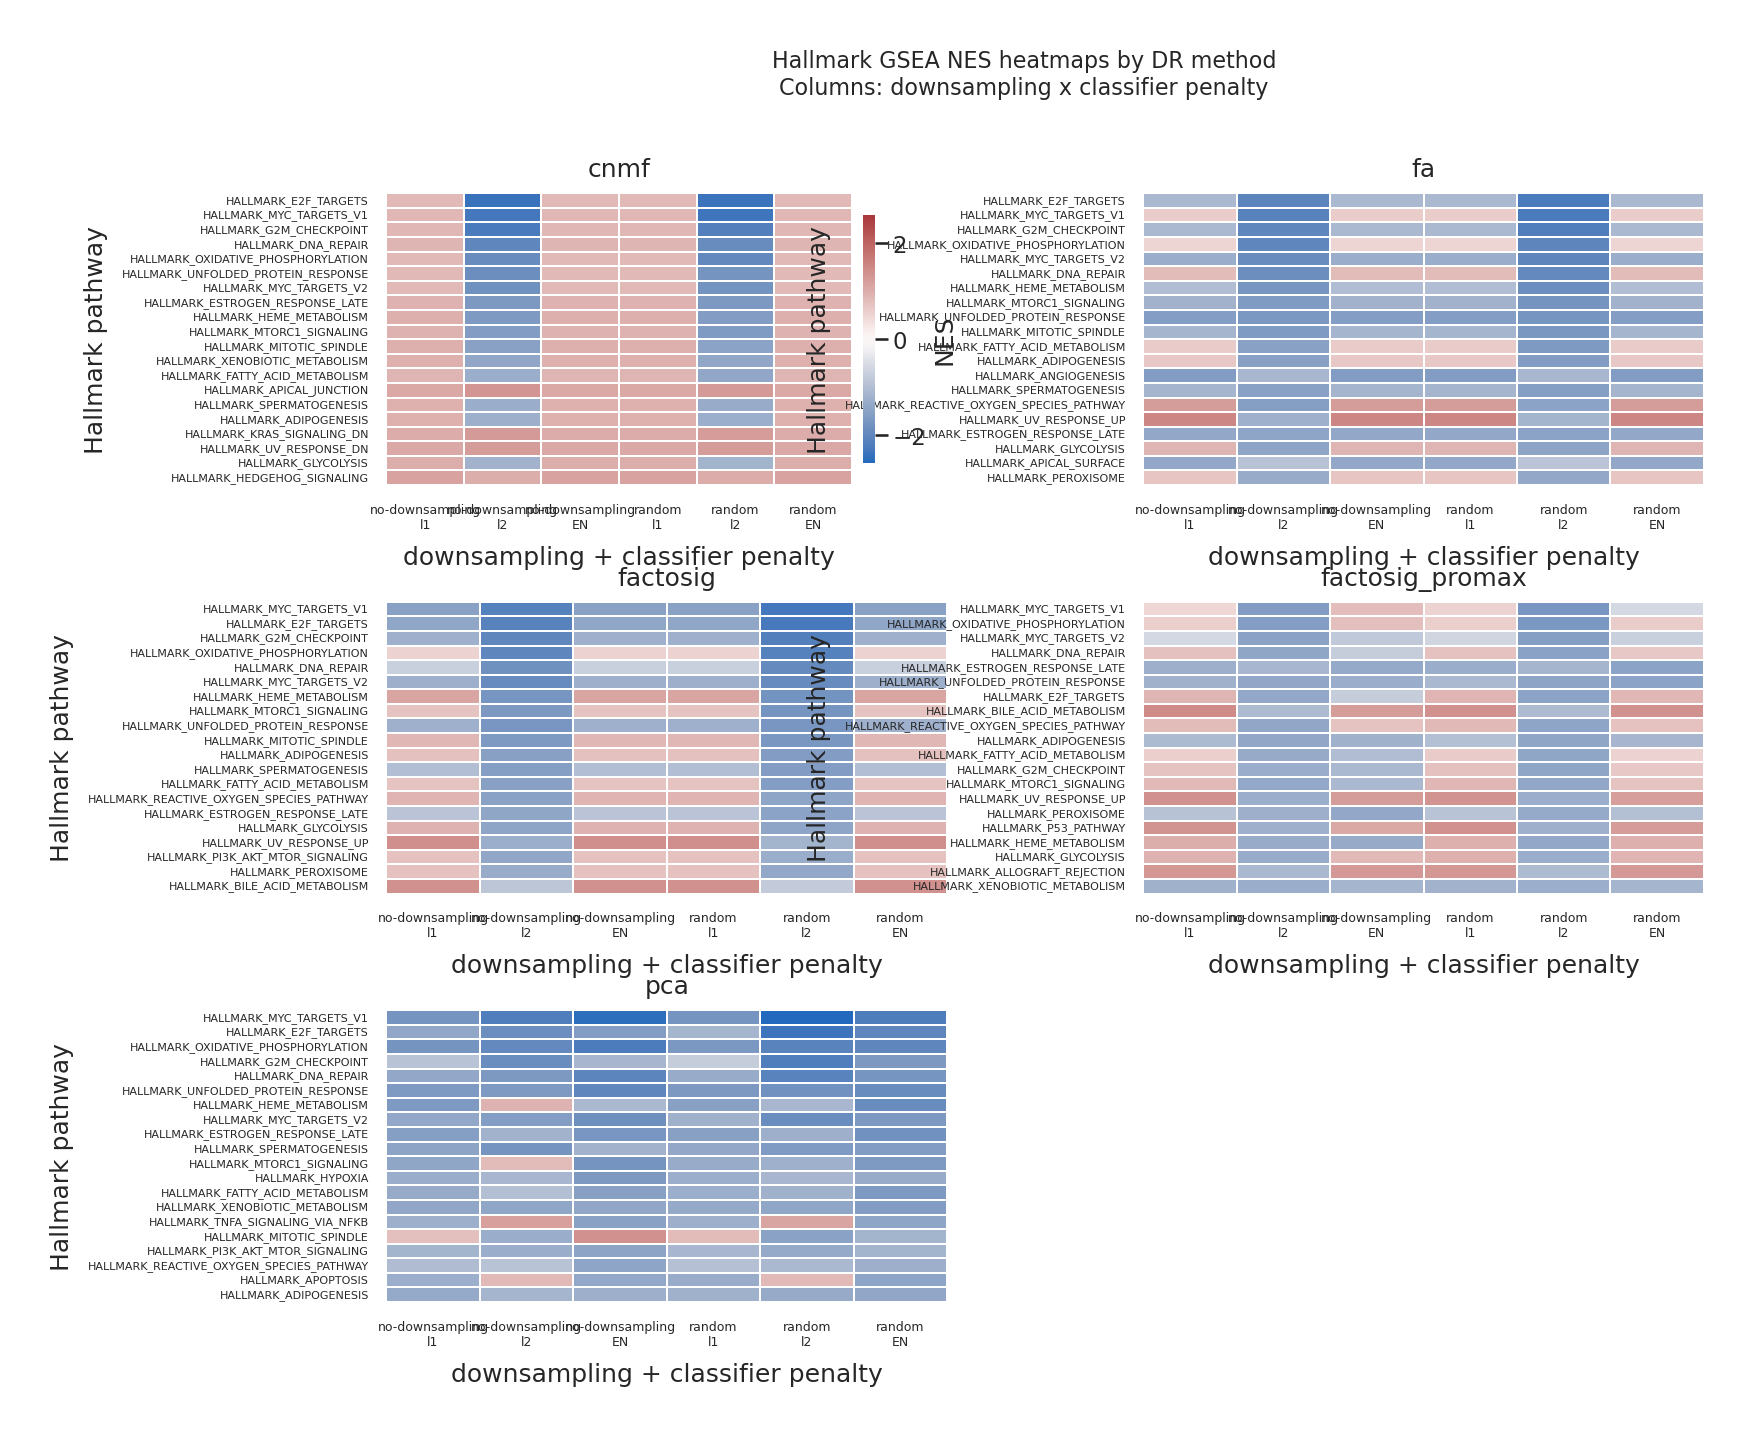

In [11]:
# Hallmark GSEA NES heatmaps split by DR method, downsampling, and penalty

GSEA_ROOT = OUTPUT_DIR / f"predictive_signature_hallmark_gsea__{SELECTION_MODE}"
NES_LONG_CSV = GSEA_ROOT / "hallmark_gsea_nes_long_per_selected_model.csv"

if "nes_long" in globals() and isinstance(nes_long, pd.DataFrame) and not nes_long.empty:
    nes_plot_long = nes_long.copy()
else:
    if not NES_LONG_CSV.exists():
        raise FileNotFoundError(f"Could not find NES table: {NES_LONG_CSV}")
    nes_plot_long = pd.read_csv(NES_LONG_CSV)


def plot_hallmark_nes_heatmaps_by_method(
    nes_long_df: pd.DataFrame,
    n_terms_per_method: int = 20,
    fdr_max: float | None = None,
    method_order: list[str] | None = None,
    downsampling_order: list[str] | None = None,
    penalty_order: list[str] | None = None,
):
    d = nes_long_df.copy()
    d["NES"] = pd.to_numeric(d["NES"], errors="coerce")
    d["FDR"] = pd.to_numeric(d.get("FDR"), errors="coerce")
    d = d.dropna(subset=["NES"]).copy()

    if fdr_max is not None:
        d = d[d["FDR"].notna() & (d["FDR"] <= fdr_max)].copy()

    if d.empty:
        raise ValueError("No Hallmark NES rows available after filtering.")

    if method_order is None:
        method_order = sorted(d["method"].dropna().unique().tolist())
    if downsampling_order is None:
        downsampling_order = ["none", "random"]
    if penalty_order is None:
        penalty_order = ["l1", "l2", "elasticnet"]

    penalty_display = {"l1": "l1", "l2": "l2", "elasticnet": "EN"}
    downsampling_display = {"none": "no-downsampling", "random": "random"}

    d["combo"] = d["downsampling"].astype(str) + "|" + d["penalty"].astype(str)
    combo_order = [f"{ds}|{pen}" for ds in downsampling_order for pen in penalty_order]
    combo_display = {
        f"{ds}|{pen}": f"{downsampling_display.get(ds, ds)}\n{penalty_display.get(pen, pen)}"
        for ds in downsampling_order
        for pen in penalty_order
    }

    top_terms_by_method = {}
    for method in method_order:
        sub = d[d["method"] == method].copy()
        if sub.empty:
            continue
        scores = (
            sub.groupby("term", observed=False)["NES"]
            .apply(lambda s: np.nanmax(np.abs(s.values)))
            .sort_values(ascending=False)
        )
        top_terms_by_method[method] = scores.head(n_terms_per_method).index.tolist()

    vmax = float(np.nanmax(np.abs(d["NES"].values)))
    vmax = vmax if np.isfinite(vmax) and vmax > 0 else 1e-6

    n_methods = len(method_order)
    ncols = min(2, max(1, n_methods))
    nrows = int(np.ceil(n_methods / ncols))
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(8.5 * ncols, max(4.8 * nrows, 6.0)),
        squeeze=False,
    )
    axes_flat = axes.ravel()

    for i, method in enumerate(method_order):
        ax = axes_flat[i]
        sub = d[d["method"] == method].copy()
        top_terms = top_terms_by_method.get(method, [])
        if sub.empty or not top_terms:
            ax.text(0.5, 0.5, "No NES results", ha="center", va="center")
            ax.set_title(method)
            ax.axis("off")
            continue

        mat = sub.pivot_table(index="term", columns="combo", values="NES", aggfunc="mean")
        mat = mat.reindex(index=top_terms, columns=combo_order)
        present_cols = [c for c in combo_order if c in mat.columns]
        mat = mat.reindex(columns=present_cols)

        sns.heatmap(
            mat,
            cmap="vlag",
            center=0,
            vmin=-vmax,
            vmax=vmax,
            linewidths=0.3,
            linecolor="white",
            xticklabels=[combo_display[c] for c in mat.columns],
            yticklabels=1,
            cbar=(i == 0),
            cbar_kws={"label": "NES", "shrink": 0.85, "pad": 0.02},
            ax=ax,
        )
        ax.set_title(method, pad=12)
        ax.set_xlabel("downsampling + classifier penalty", labelpad=10)
        ax.set_ylabel("Hallmark pathway", labelpad=10)
        ax.tick_params(axis="x", labelrotation=0, labelsize=9, pad=4)
        ax.tick_params(axis="y", labelsize=8)

    for j in range(n_methods, len(axes_flat)):
        axes_flat[j].axis("off")

    title_suffix = f" (FDR <= {fdr_max})" if fdr_max is not None else ""
    fig.suptitle(
        f"Hallmark GSEA NES heatmaps by DR method{title_suffix}\nColumns: downsampling x classifier penalty",
        fontsize=16,
        y=0.98,
    )
    fig.subplots_adjust(top=0.88, wspace=0.35, hspace=0.4)
    plt.show()


plot_hallmark_nes_heatmaps_by_method(
    nes_plot_long,
    n_terms_per_method=20,
    fdr_max=None,
)

# Optional stricter version showing only significant pathways when available:
# plot_hallmark_nes_heatmaps_by_method(nes_plot_long, n_terms_per_method=15, fdr_max=0.05)


Using Hallmark GMT: /home/minhang/mds_project/data/cohort_adata/gene_sets/h.all.v2024.1.Hs.symbols.gmt


,method,downsampling,penalty,model_uid,n_sig_pathways_fdr_lt_0p05
0,cnmf,none,elasticnet,cnmf|none|elasticnet,0
1,cnmf,none,l1,cnmf|none|l1,0
2,cnmf,none,l2,cnmf|none|l2,11
3,cnmf,random,elasticnet,cnmf|random|elasticnet,0
4,cnmf,random,l1,cnmf|random|l1,0
5,cnmf,random,l2,cnmf|random|l2,11
6,fa,none,elasticnet,fa|none|elasticnet,0
7,fa,none,l1,fa|none|l1,0
8,fa,none,l2,fa|none|l2,16
9,fa,random,elasticnet,fa|random|elasticnet,0


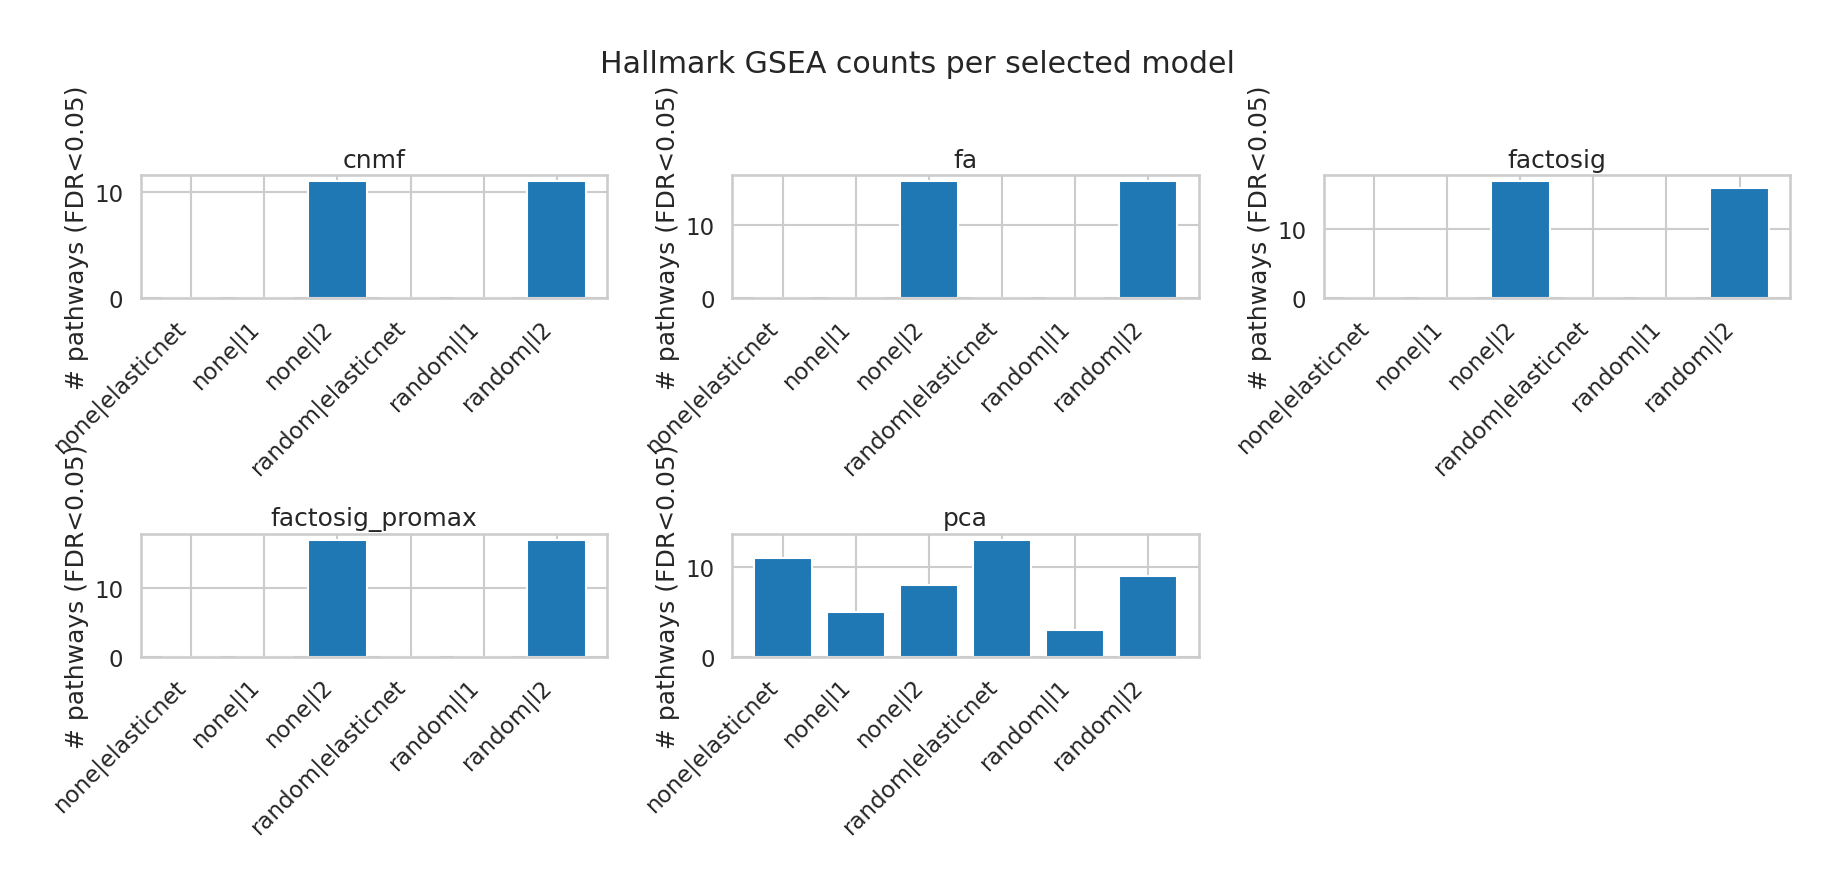

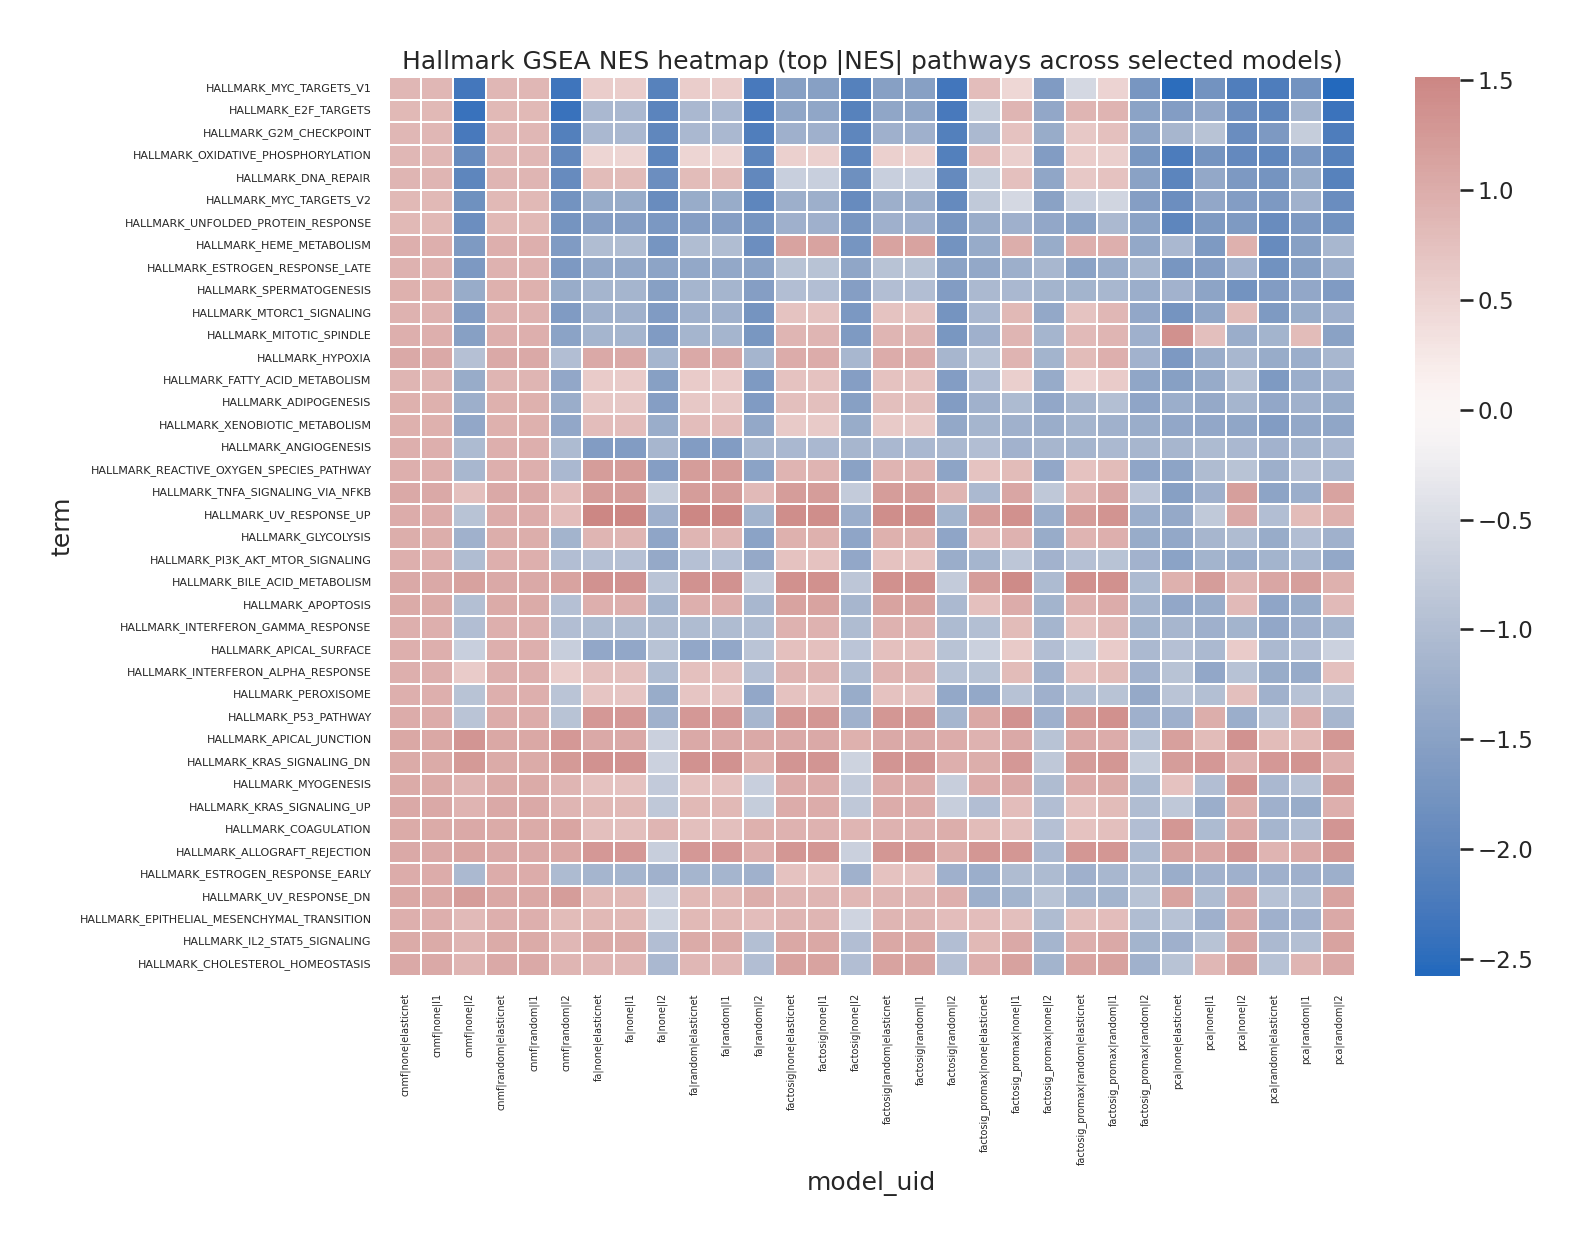

Saved Hallmark GSEA outputs to: /home/minhang/mds_project/sc_classification/scripts/comprehensive_run/notebooks/outputs/plan1c_k40_full_reg_path_analysis_20260319/predictive_signature_hallmark_gsea__most_parsimonious_nonzero
Per-model NES bar plots are saved as nes_top_pos_neg_barplot.png under each model folder.


In [12]:
# Hallmark GSEA on predictive signatures for the selected most-parsimonious non-zero models
from typing import Optional
import math
import os
import re

try:
    import gseapy as gp
except Exception:
    gp = None
    print("Install gseapy to run this section: pip install gseapy")

GSEA_THREADS = int(os.environ.get("GSEA_THREADS", "4"))
GSEA_PERM = int(os.environ.get("GSEA_PERM", "200"))
GSEA_MIN_SIZE = int(os.environ.get("GSEA_MIN_SIZE", "15"))
GSEA_MAX_SIZE = int(os.environ.get("GSEA_MAX_SIZE", "500"))


def _safe_name(x: str) -> str:
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", str(x)).strip("_")


def _resolve_hallmark_gmt() -> Optional[Path]:
    env_path = os.environ.get("HALLMARK_GMT", "").strip()
    if env_path:
        p = Path(env_path)
        if p.exists():
            return p

    candidates = [
        Path("/home/minhang/mds_project/data/cohort_adata/gene_sets/h.all.v2024.1.Hs.symbols.gmt"),
        Path("data/msigdb/h.all.v2023.1.Hs.symbols.gmt"),
        Path("data/msigdb/h.all.v7.5.1.symbols.gmt"),
        Path("sc_classification/data/msigdb/h.all.v2023.2.Hs.symbols.gmt"),
        Path("sc_classification/data/msigdb/h.all.v2023.1.Hs.symbols.gmt"),
        Path("sc_classification/data/msigdb/h.all.v7.5.1.symbols.gmt"),
    ]
    for p in candidates:
        if p.exists():
            return p

    hits = sorted(Path(".").rglob("h.all*.gmt"))
    return hits[0] if hits else None


def _read_prerank_report_auto(report_csv: Path) -> pd.DataFrame:
    for sep in [",", "\t", None]:
        try:
            if sep is None:
                df = pd.read_csv(report_csv)
            else:
                df = pd.read_csv(report_csv, sep=sep)
            if df.shape[1] > 1:
                return df
        except Exception:
            continue
    return pd.read_csv(report_csv)


def run_or_read_prerank(series: pd.Series, gene_sets: Path, out_dir: Path) -> Optional[pd.DataFrame]:
    out_dir.mkdir(parents=True, exist_ok=True)

    canonical_cache = out_dir / "prerank_res2d_cached.csv"
    if canonical_cache.exists():
        return pd.read_csv(canonical_cache)

    report_candidates = [
        out_dir / "gseapy.gene_set.prerank.report.csv",
        out_dir / "gseapy.prerank.gene_sets.report.csv",
    ]
    for report_csv in report_candidates:
        if report_csv.exists():
            df = _read_prerank_report_auto(report_csv)
            df.to_csv(canonical_cache, index=False)
            return df

    if gp is None:
        return None

    rank_df = series.reset_index()
    rank_df.columns = ["gene", "score"]

    res = gp.prerank(
        rnk=rank_df,
        gene_sets=str(gene_sets),
        threads=GSEA_THREADS,
        permutation_num=GSEA_PERM,
        outdir=str(out_dir),
        seed=0,
        min_size=GSEA_MIN_SIZE,
        max_size=GSEA_MAX_SIZE,
        no_plot=True,
        format="png",
        verbose=False,
    )
    df = res.res2d.copy()
    df.to_csv(canonical_cache, index=False)
    return df


def _pick_col(cols: list[str], candidates: list[str]) -> Optional[str]:
    lower_map = {c.lower(): c for c in cols}
    for c in candidates:
        if c.lower() in lower_map:
            return lower_map[c.lower()]
    return None


hallmark_gmt = _resolve_hallmark_gmt()
if hallmark_gmt is None:
    print("No Hallmark GMT found. Set HALLMARK_GMT env var or place h.all*.gmt in repo.")
else:
    print("Using Hallmark GMT:", hallmark_gmt)

    model_meta = pooled_selected[["method", "downsampling", "penalty"]].copy()
    model_meta["model_uid"] = (
        model_meta["method"].astype(str)
        + "|"
        + model_meta["downsampling"].astype(str)
        + "|"
        + model_meta["penalty"].astype(str)
    )
    model_meta = model_meta.drop_duplicates(subset=["model_uid"]).sort_values(
        ["method", "downsampling", "penalty"]
    ).reset_index(drop=True)

    gsea_root = OUTPUT_DIR / f"predictive_signature_hallmark_gsea__{SELECTION_MODE}"
    gsea_root.mkdir(parents=True, exist_ok=True)

    count_rows = []
    nes_rows = []

    for _, r in model_meta.iterrows():
        model_uid = r["model_uid"]
        if model_uid not in sig_df.columns:
            continue

        rank = sig_df[model_uid].sort_values(ascending=False)
        out_dir = (
            gsea_root
            / _safe_name(r["method"])
            / _safe_name(f"{r['downsampling']}|{r['penalty']}")
        )
        df = run_or_read_prerank(rank, hallmark_gmt, out_dir)

        if df is None or df.empty:
            count_rows.append(
                {
                    "method": r["method"],
                    "downsampling": r["downsampling"],
                    "penalty": r["penalty"],
                    "model_uid": model_uid,
                    "n_sig_pathways_fdr_lt_0p05": np.nan,
                }
            )
            continue

        term_col = _pick_col(df.columns.tolist(), ["Term", "term", "NAME", "name"])
        nes_col = _pick_col(df.columns.tolist(), ["NES", "nes"])
        fdr_col = _pick_col(df.columns.tolist(), ["FDR q-val", "fdr", "fdr_q-val", "fdr_q_value"])

        if fdr_col is not None:
            fdr_numeric = pd.to_numeric(df[fdr_col], errors="coerce")
            n_sig = int((fdr_numeric < 0.05).sum())
        else:
            fdr_numeric = pd.Series(np.nan, index=df.index)
            n_sig = np.nan

        count_rows.append(
            {
                "method": r["method"],
                "downsampling": r["downsampling"],
                "penalty": r["penalty"],
                "model_uid": model_uid,
                "n_sig_pathways_fdr_lt_0p05": n_sig,
            }
        )

        if term_col is not None and nes_col is not None:
            tmp = df[[term_col, nes_col]].copy()
            tmp.columns = ["term", "NES"]
            tmp["NES"] = pd.to_numeric(tmp["NES"], errors="coerce")
            tmp["FDR"] = fdr_numeric.values
            tmp = tmp.dropna(subset=["NES"]).reset_index(drop=True)
            tmp["method"] = r["method"]
            tmp["downsampling"] = r["downsampling"]
            tmp["penalty"] = r["penalty"]
            tmp["model_uid"] = model_uid
            nes_rows.append(tmp)

            top_pos = tmp.nlargest(8, "NES")
            top_neg = tmp.nsmallest(8, "NES")
            plot_df = pd.concat([top_neg, top_pos], ignore_index=True)
            if not plot_df.empty:
                plot_df = plot_df.sort_values("NES")
                fig, ax = plt.subplots(figsize=(10, 6))
                colors = np.where(plot_df["NES"] >= 0, "#b2182b", "#2166ac")
                ax.barh(plot_df["term"], plot_df["NES"], color=colors)
                ax.axvline(0, color="black", linewidth=1)
                ax.set_title(f"NES: {model_uid}")
                ax.set_xlabel("Normalized Enrichment Score (NES)")
                plt.tight_layout()
                fig.savefig(out_dir / "nes_top_pos_neg_barplot.png", dpi=160)
                plt.close(fig)

    gsea_counts = pd.DataFrame(count_rows).sort_values(["method", "downsampling", "penalty"])
    display(gsea_counts)
    gsea_counts.to_csv(gsea_root / "hallmark_gsea_counts_per_selected_model.csv", index=False)

    if not gsea_counts.empty:
        methods = sorted(gsea_counts["method"].dropna().unique().tolist())
        n_methods = len(methods)
        ncols = min(3, max(1, n_methods))
        nrows = math.ceil(n_methods / ncols)

        fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows), squeeze=False)
        axes_flat = axes.ravel()

        for i, method in enumerate(methods):
            ax = axes_flat[i]
            sub = gsea_counts[gsea_counts["method"] == method].copy()
            if sub.empty:
                ax.text(0.5, 0.5, "No results", ha="center", va="center")
                ax.set_title(method)
                ax.axis("off")
                continue

            sub["combo"] = sub["downsampling"].astype(str) + "|" + sub["penalty"].astype(str)
            sub = sub.sort_values(["downsampling", "penalty"]).reset_index(drop=True)

            ax.bar(np.arange(len(sub)), sub["n_sig_pathways_fdr_lt_0p05"].values)
            ax.set_xticks(np.arange(len(sub)))
            ax.set_xticklabels(sub["combo"].tolist(), rotation=45, ha="right")
            ax.set_ylabel("# pathways (FDR<0.05)")
            ax.set_title(method)

        for j in range(n_methods, len(axes_flat)):
            axes_flat[j].axis("off")

        fig.suptitle("Hallmark GSEA counts per selected model", y=1.02)
        plt.tight_layout()
        plt.show()

    if nes_rows:
        nes_long = pd.concat(nes_rows, ignore_index=True)
        nes_long.to_csv(gsea_root / "hallmark_gsea_nes_long_per_selected_model.csv", index=False)

        nes_mat = nes_long.pivot_table(index="term", columns="model_uid", values="NES", aggfunc="mean")
        col_order = [c for c in model_meta["model_uid"].tolist() if c in nes_mat.columns]
        nes_mat = nes_mat.reindex(columns=col_order)

        top_terms = nes_mat.abs().max(axis=1).sort_values(ascending=False).head(40).index
        nes_top = nes_mat.loc[top_terms]

        fig, ax = plt.subplots(figsize=(max(16, 0.35 * nes_top.shape[1]), 12))
        sns.heatmap(
            nes_top,
            cmap="vlag",
            center=0,
            linewidths=0.15,
            linecolor="white",
            xticklabels=1,
            yticklabels=1,
            ax=ax,
        )
        ax.set_title("Hallmark GSEA NES heatmap (top |NES| pathways across selected models)")
        ax.tick_params(axis="x", labelrotation=90, labelsize=7)
        ax.tick_params(axis="y", labelsize=8)
        plt.tight_layout()
        plt.show()

        nes_top.to_csv(gsea_root / "hallmark_gsea_nes_matrix_top40_terms.csv")

    print("Saved Hallmark GSEA outputs to:", gsea_root)
    print("Per-model NES bar plots are saved as nes_top_pos_neg_barplot.png under each model folder.")